# Probability-Space Calibration with PAV + Box-Safe PCHIP for Binary Classification

## The Problem

A model emits scores $\hat p\in[0,1]$ for binary labels $y\in\{0,1\}$. It is **calibrated** if $\mathbb P(y=1\mid \hat p)=\hat p$. In practice it is not, so we want a map $h:[0,1]\to[0,1]$ such that $h(\hat p)$ *is* calibrated, with these requirements:

1. **Monotone** — $h$ must not reorder scores, so ROC AUC is untouched.
2. **Injective in practice** — distinct scores should stay distinct (no ties introduced).
3. **Streaming fit** — the data may not fit in memory; fitting should need only mergeable summaries.
4. **Noise-aware** — an aggregated bin with 12 samples must not carry the same authority as one with 12,000.
5. **Cheap inference** — a deployed $h(\hat p)$ should pay a few nanoseconds per call (in C++).

## Pipeline Overview

Below is a overview in table format for the calibration pipeline implemented in YDF for solving the above problem.
A more detailed description and graphic illustration follows afterwards.

| Pipeline Step | Design Choice | Rationale |
|---|---|---|
| D1 | Fixed-width bins storing sufficient statistics $(n,\sum\hat p,\sum y)$ | streaming, mergeable fit; O(1) bin lookup |
| D2 | PAV pooling that sums *raw accumulators* | exact monotone MLE; correct weighting for free |
| D3 | Optional significance merge (`z_threshold`) | removes statistically meaningless wiggle |
| D4 | Interpolate with PCHIP instead of using the step function | no ties, smooth, shape-preserving |
| D5 | Slopes $d_k=\min(\text{weighted harmonic mean},\,3\min\delta)$ | monotonicity is *algebraic*, not patched |
| D6 | Inverse-variance confidence weights $n/\hat p(1-\hat p)$ | noisy pools influence slopes less |
| D7 | No forced anchors at $(0,0)$ and $(1,1)$ | no fabricated data points |
| D8 | Lookup table of $\delta(p)=h(p)-p$ on a uniform grid | O(1) inference, thread-safe |

The calibrator turns millions of (score, label) pairs into a small, smooth, increasing curve in four steps. Each step keeps only what the next one needs.

**1. Bucket the scores (D1).** Split $[0,1]$ into $K$ bins of equal width. Each bin keeps three running totals: how many examples fell in it ($n$), the sum of their scores ($\sum\hat p$), and how many were positive ($\sum y$). These totals are enough to compute every later step. Two partial fits combine by adding their totals, so the data never has to fit in memory, and finding a score's bin takes one multiplication.

**2. Make the rates go up (D2, D3).** Each bin's observed positive rate is noisy and zig-zags. The Pool Adjacent Violators (PAV) algorithm scans from left to right. Whenever a bin's rate is lower than the rate to its left, it merges the two by adding their totals. The result is a staircase of *pools* whose rates never go down. This is the best-fitting monotone answer (the maximum-likelihood fit), and a pool built from 10,000 examples counts for more than one built from 10, with no extra work. You can also merge neighbouring pools whose rates differ by less than $z$ standard errors. This removes steps that are probably just noise.

**3. Draw a smooth curve through the staircase (D4–D7).** If we used the staircase directly, every score in a pool would get the same output, which creates ties. Instead, each pool becomes one *knot* at (mean score, positive rate), and the knots are joined with a piecewise cubic (PCHIP). The slope at each knot is chosen so that:
* the curve provably never decreases, because of how the slope is computed rather than a fix applied afterwards (D5);
* pools with many examples steer the curve more than less-populated pools (D6);
* nothing is pinned to $(0,0)$ or $(1,1)$. Past the outermost knots, where we have no data, the curve stays flat (D7).

**4. Precompute the answers (D8).** Evaluate the correction $\delta(p)=h(p)-p$ on a fine uniform grid and store it. At prediction time, a score is mapped to its grid cell in one step, the stored corrections on either side are linearly interpolated, and the result is added to the score: $h(\hat p)=\hat p+\delta(\hat p)$.

The figure below runs these steps on a toy sample of 3,000 examples with 20 bins.

In [41]:
#@title Imports and Setup

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.width", 200)

# --- plotting style: light surface, one validated categorical order, recessive grid -----------
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100", magenta="#e87ba4")

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})


def label(ax, x, y, text, color, dx=6, dy=0, ha="left", size=8.5, backgroundcolor='#00000000'):
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", color=color,
                fontsize=size, ha=ha, va="center", backgroundcolor=backgroundcolor)


def key(ax, items, x=0.04, y=0.95, step=0.075, size=8.5):
    """Direct-label key in empty axes space (identity is never colour-alone: each entry carries a glyph)."""
    for i, (text, color) in enumerate(items):
        ax.text(x, y - i * step, text, color=color, transform=ax.transAxes, fontsize=size, va="top")

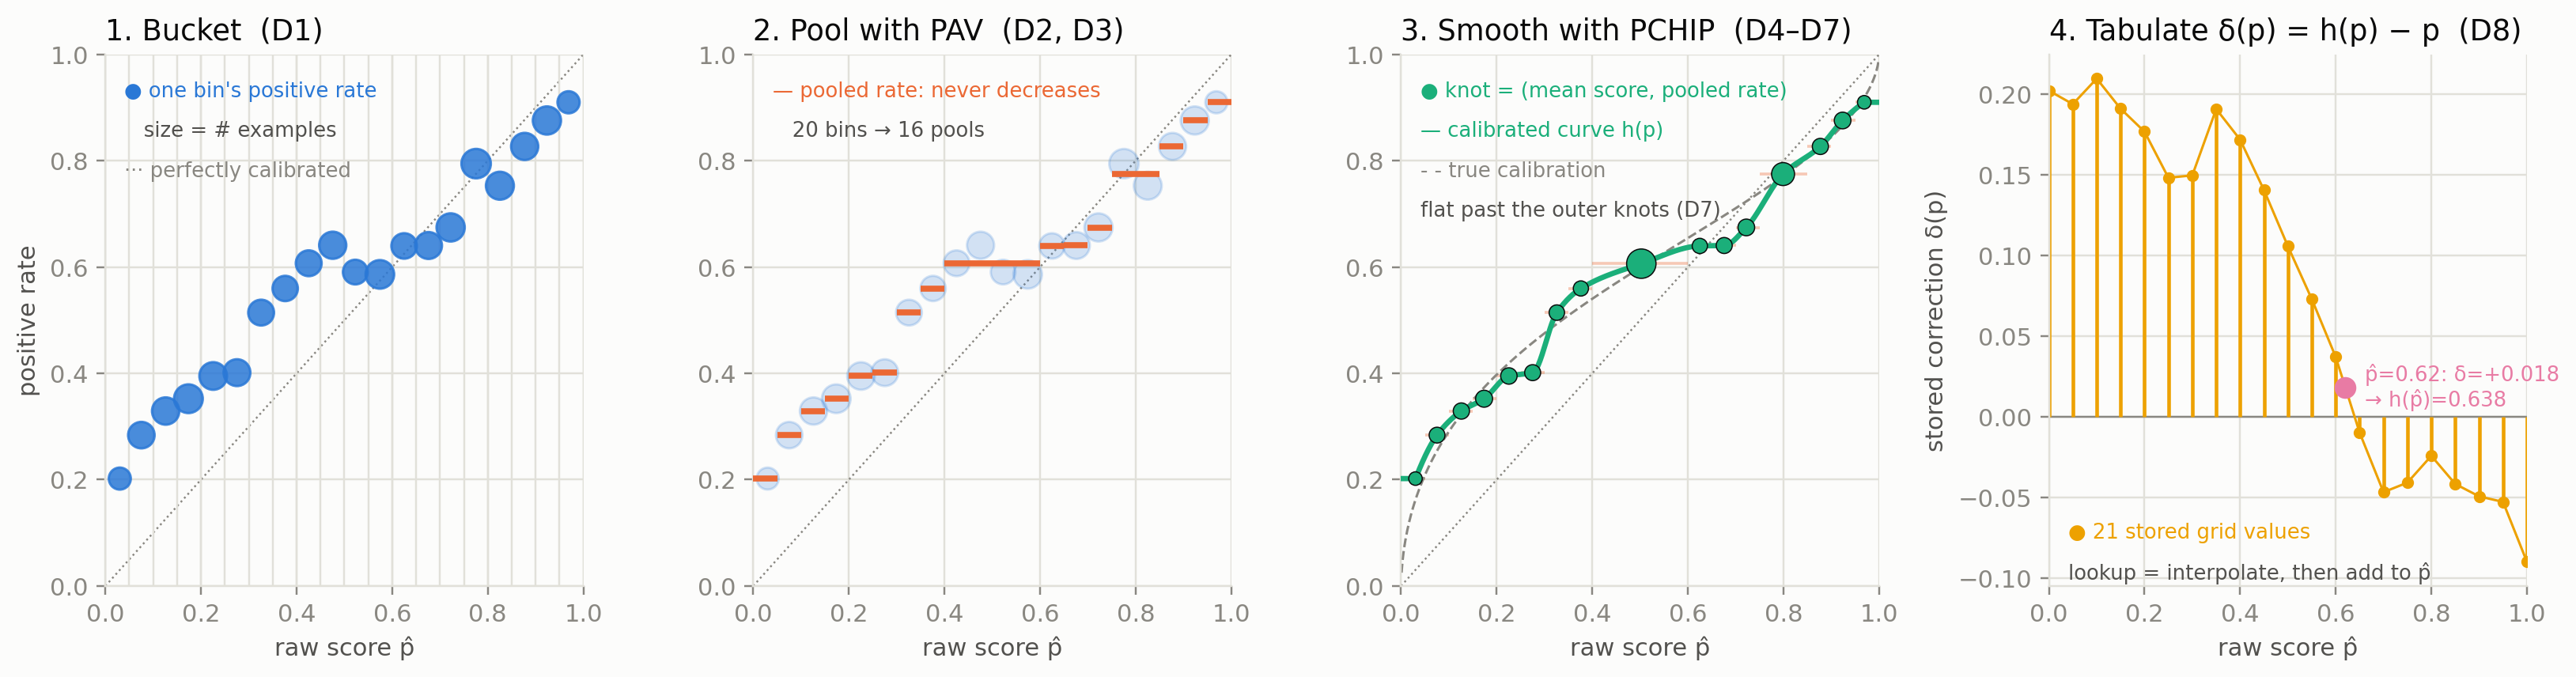

In [43]:
#@title Pipeline Overview

# Pipeline at a glance on a small toy sample (schematic: uses SciPy's default PCHIP slopes;
# the weighted, box-safe version of each stage is built and tested in D1-D8 below).
rng = np.random.default_rng(3)
s = 1 / (1 + np.exp(-rng.normal(0.0, 1.6, 3000)))                         # raw scores
truth = lambda p: 1 / (1 + np.exp(-(np.log(p / (1 - p)) / 1.7 + 0.4)))   # true P(y=1 | score)
yy = (rng.uniform(size=s.size) < truth(s)).astype(float)

# 1. Bin: keep only (n, sum p, sum y) per equal-width bin.
K = 20
b = np.minimum((s * K).astype(int), K - 1)
n = np.bincount(b, minlength=K).astype(float)
sp = np.bincount(b, weights=s, minlength=K)
sy = np.bincount(b, weights=yy, minlength=K)
keep = n > 0
lo = np.arange(K)[keep] / K
n, sp, sy = n[keep], sp[keep], sy[keep]

# 2. Pool: PAV on the raw accumulators (merge leftwards while the rate fails to rise).
pools = []                                   # [n, sum p, sum y, first bin, last bin]
for i in range(len(n)):
    pools.append([n[i], sp[i], sy[i], i, i])
    while len(pools) > 1 and pools[-2][2] / pools[-2][0] >= pools[-1][2] / pools[-1][0]:
        c = pools.pop(); a = pools[-1]
        pools[-1] = [a[0] + c[0], a[1] + c[1], a[2] + c[2], a[3], c[4]]
P = np.array(pools)
xk, yk, nk = P[:, 1] / P[:, 0], P[:, 2] / P[:, 0], P[:, 0]
first, last = P[:, 3].astype(int), P[:, 4].astype(int)

# 3. Smooth: PCHIP through the knots, flat outside them.
f = PchipInterpolator(xk, yk)
h = lambda p: f(np.clip(p, xk[0], xk[-1]))

# 4. Tabulate: delta(p) = h(p) - p on a uniform grid.
g = np.linspace(0, 1, 21)
delta = h(g) - g

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
grid = np.linspace(0.001, 0.999, 500)
size = lambda m: 8 + 140 * m / m.max()
def steps(a, **kw):
    a.hlines(yk, lo[first], lo[last] + 1 / K, **kw)

for a in ax[:3]:
    a.plot([0, 1], [0, 1], color=MUTED, lw=0.8, ls=":")
    a.set(xlim=(0, 1), ylim=(0, 1), xlabel="raw score p̂")
ax[0].set_ylabel("positive rate")

ax[0].vlines(np.arange(K + 1) / K, 0, 1, color=GRID, lw=0.8)
ax[0].scatter(sp / n, sy / n, s=size(n), color=C["blue"], alpha=0.85, zorder=3)
ax[0].set_title("1. Bucket  (D1)", loc="left")
key(ax[0], [("● one bin's positive rate", C["blue"]), ("   size = # examples", INK2),
            ("··· perfectly calibrated", MUTED)])

ax[1].scatter(sp / n, sy / n, s=size(n), color=C["blue"], alpha=0.2, zorder=2)
steps(ax[1], color=C["orange"], lw=2.5, zorder=3)
ax[1].set_title("2. Pool with PAV  (D2, D3)", loc="left")
key(ax[1], [("— pooled rate: never decreases", C["orange"]),
            (f"   {len(n)} bins → {len(xk)} pools", INK2)])

steps(ax[2], color=C["orange"], lw=1.2, alpha=0.35)
ax[2].plot(grid, truth(grid), color=MUTED, lw=1, ls="--")
ax[2].plot(grid, h(grid), color=C["aqua"], lw=2.2, zorder=3)
ax[2].scatter(xk, yk, s=size(nk), color=C["aqua"], edgecolor=INK, lw=0.5, zorder=4)
ax[2].set_title("3. Smooth with PCHIP  (D4–D7)", loc="left")
key(ax[2], [("● knot = (mean score, pooled rate)", C["aqua"]),
            ("— calibrated curve h(p)", C["aqua"]), ("- - true calibration", MUTED),
            ("flat past the outer knots (D7)", INK2)])

p0 = 0.62; d0 = np.interp(p0, g, delta)
ax[3].axhline(0, color=MUTED, lw=0.8)
ax[3].vlines(g, 0, delta, color=C["yellow"], lw=1.5)
ax[3].plot(g, delta, "o-", color=C["yellow"], ms=4, lw=1)
ax[3].plot([p0], [d0], "o", color=C["magenta"], ms=8, zorder=4)
label(ax[3], p0, d0, f"p̂={p0:.2f}: δ={d0:+.3f}\n→ h(p̂)={p0 + d0:.3f}", C["magenta"], dx=8)
ax[3].set(xlim=(0, 1), xlabel="raw score p̂", ylabel="stored correction δ(p)")
ax[3].set_title("4. Tabulate δ(p) = h(p) − p  (D8)", loc="left")
key(ax[3], [(f"● {len(g)} stored grid values", C["yellow"]),
            ("lookup = interpolate, then add to p̂", INK2)], y=0.12)

fig.tight_layout(); plt.show()

## Detailed Walkthrough

### Simulated Logit Model

To judge a calibrator we need the *true* calibration function, so we simulate it. The model's logit is $x\sim\mathcal N(0,3^2)$ and its raw score is $\hat p=\sigma(x)$. The truth is

$$\mathbb P(y=1\mid x)=\sigma\!\Big(\tfrac{x}{T}-s\,e^{-\frac12((x-c)/w)^2}\Big),\qquad T=2.2,\; c=2,\; w=0.8,\; s=0.35,$$

i.e. the model is **overconfident** (temperature $T>1$) and has a **local bump** of miscalibration around $x=2$. A one-parameter fix (temperature / Platt scaling) cannot capture the bump; a nonparametric calibrator can.**bold text**

In [44]:
#@title Definitions and Setup

def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
def logit(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))

def _core(x):  # true P(y=1 | logit x) before any label-noise floor
    return sigmoid(x / 2.2 - 0.35 * np.exp(-0.5 * ((x - 2.0) / 0.8) ** 2))

def true_h(p, floor=0.0):
    """Exact calibration function as a function of the raw SCORE p."""
    return floor + (1 - 2 * floor) * _core(logit(p))

def make_data(n, seed, floor=0.0):
    rng = np.random.default_rng(seed)
    x = rng.normal(0.0, 3.0, n)
    p = sigmoid(x)
    y = (rng.uniform(size=n) < floor + (1 - 2 * floor) * _core(x)).astype(float)
    return p, y

# ---- metrics ------------------------------------------------------------------------------
def brier_each(p, y): return (p - y) ** 2
def logloss_each(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))
def ece(p, y, nb=15):
    idx = np.minimum((np.clip(p, 0, 1) * nb).astype(np.int64), nb - 1)
    sp = np.bincount(idx, weights=p, minlength=nb); sy = np.bincount(idx, weights=y, minlength=nb)
    return np.sum(np.abs(sp - sy)) / len(p)          # = sum_b (n_b/N) |mean p - mean y|
def paired(a, b):
    """mean(a-b) and its standard error, for per-sample losses a, b on the SAME samples."""
    d = a - b
    return d.mean(), d.std(ddof=1) / np.sqrt(len(d))

N_TOTAL, N_BINS = 300_000, 400
p_all, y_all = make_data(N_TOTAL, seed=7)
cut = int(0.7 * N_TOTAL)
p_tr, y_tr, p_va, y_va = p_all[:cut], y_all[:cut], p_all[cut:], y_all[cut:]
print(f"train {len(p_tr):,}  val {len(p_va):,}  base rate {y_tr.mean():.3f}  "
      f"raw-score ECE(15) on val = {ece(p_va, y_va):.4f}")

train 210,000  val 90,000  base rate 0.484  raw-score ECE(15) on val = 0.1333


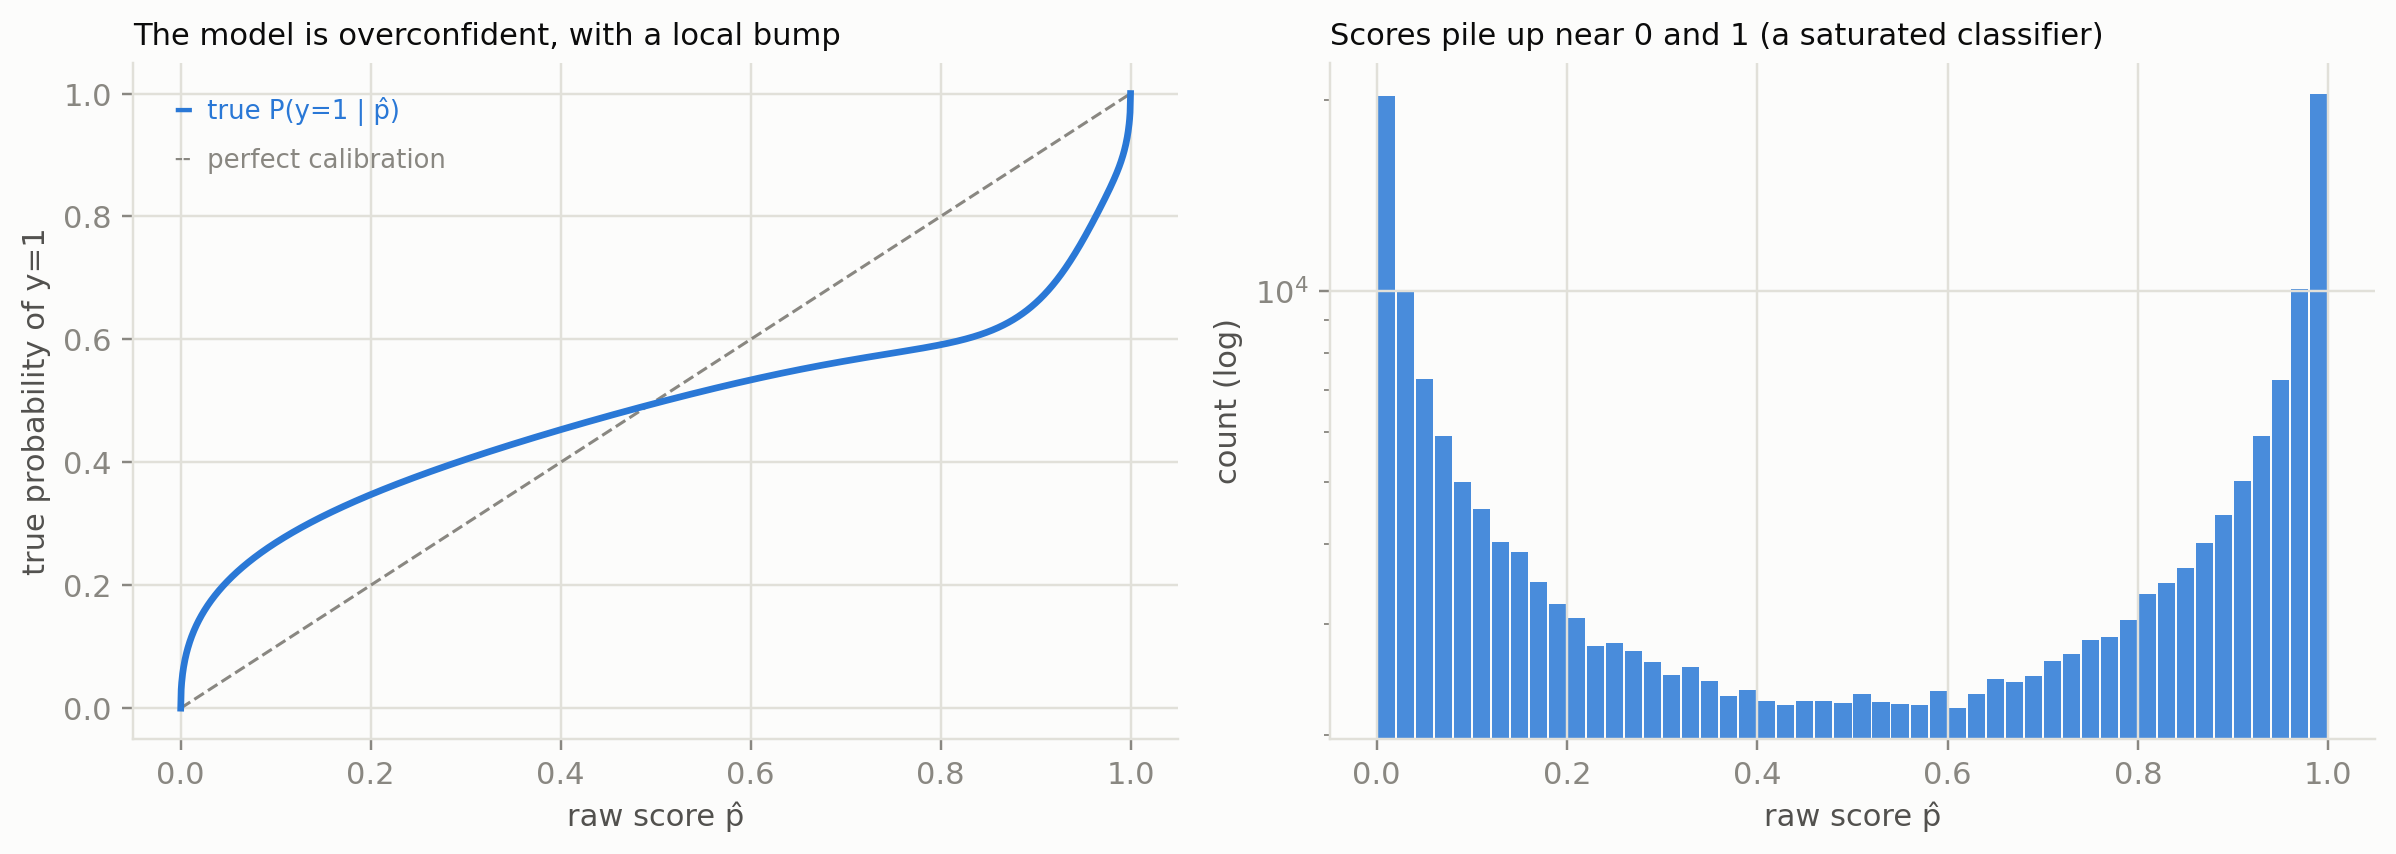

In [45]:
#@title Reliability Diagram and Score Distribution

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
g = np.linspace(0, 1, 2001)
ax[0].plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax[0].plot(g, true_h(g), color=C["blue"], lw=2.2)
key(ax[0], [("━  true P(y=1 | p̂)", C["blue"]), ("╌  perfect calibration", MUTED)])
ax[0].set_xlabel("raw score p̂"); ax[0].set_ylabel("true probability of y=1")
ax[0].set_title("The model is overconfident, with a local bump", loc="left", fontsize=10, color=INK)

ax[1].hist(p_tr, bins=50, range=(0, 1), color=C["blue"], alpha=0.85, rwidth=0.9)
ax[1].set_yscale("log"); ax[1].set_xlabel("raw score p̂"); ax[1].set_ylabel("count (log)")
ax[1].set_title("Scores pile up near 0 and 1 (a saturated classifier)", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

### D1. Fixed-Width Bins that Store *Sufficient Statistics* (`n_bins`)

Cut $[0,1]$ into $K$ equal-width bins. For each bin $b$ keep only three numbers: $n_b$ (count), $S_b=\sum_{i\in b}y_i$ (positives) and $P_b=\sum_{i\in b}\hat p_i$ (sum of scores).

**Rationale:**

* *Sufficiency.* If we model $h$ as constant $h_b$ on bin $b$, the Bernoulli log-likelihood is
  $$\ell(h)=\sum_b\big[S_b\log h_b+(n_b-S_b)\log(1-h_b)\big],$$
  which depends on the data **only** through $(n_b,S_b)$; its maximiser is $\hat h_b=S_b/n_b$. The extra statistic $P_b$ gives the bin's mean score $\bar x_b=P_b/n_b$, which will become the *knot position* (D4/D7 explain why the mean, not the bin centre).
* *Mergeability.* $(n,S,P)$ can be combined by plain addition. So chunked, streamed or distributed accumulation gives (up to floating-point summation order) the same result as one pass: memory is $O(K)$, independent of the data size.
* *O(1) indexing.* With equal-width bins the bin of a score $p$ elides lookups and can be computed by `floor(p*K)`.

**Tradeoffs:** Equal-width bins in *probability* space are coarse where scores are sparse and wasteful where they are dense: the histogram above shows most mass in the extreme bins. Quantile bins would adapt to density, but they need a first pass over the data to find the quantiles and are not mergeable across chunks. PAV (D2) and the confidence weights (D6) are what keep sparse bins from hurting.

In [46]:
#@title Definitions and Consistency Checks

def accumulate(p, y, n_bins, acc=None):
    """Fold a chunk of (p, y) into per-bin sufficient statistics. Never drops empty bins."""
    if acc is None:
        acc = dict(n=np.zeros(n_bins), sp=np.zeros(n_bins), sy=np.zeros(n_bins))
    idx = np.minimum((np.clip(p, 0, 1) * n_bins).astype(np.int64), n_bins - 1)
    acc["n"]  += np.bincount(idx, minlength=n_bins)
    acc["sp"] += np.bincount(idx, weights=p, minlength=n_bins)
    acc["sy"] += np.bincount(idx, weights=y, minlength=n_bins)
    return acc

def finalize(acc):
    """Drop empty bins ONCE, after the last chunk. Returns sums plus the surviving bin indices."""
    nz = acc["n"] > 0
    return acc["sp"][nz], acc["sy"][nz], acc["n"][nz], np.flatnonzero(nz)

# monolithic vs. 7 irregular chunks
mono = accumulate(p_tr, y_tr, N_BINS)
chunked = None
for pc, yc in zip(np.array_split(p_tr, 7), np.array_split(y_tr, 7)):
    chunked = accumulate(pc, yc, N_BINS, chunked)
print("counts identical        :", np.array_equal(mono["n"], chunked["n"]))
print("max |Δ Σy|              :", np.max(np.abs(mono["sy"] - chunked["sy"])))
print("max relative |Δ Σp̂|     :", np.max(np.abs(mono["sp"] - chunked["sp"]) / np.maximum(mono["sp"], 1e-300)))
assert np.array_equal(mono["n"], chunked["n"]) and np.allclose(mono["sp"], chunked["sp"], rtol=1e-12)

sp_b, sy_b, n_b, bin_idx = finalize(mono)
print(f"\n{N_BINS} bins -> {len(n_b)} non-empty; fewest samples in a non-empty bin: {int(n_b.min())}, most: {int(n_b.max()):,}")

counts identical        : True
max |Δ Σy|              : 0.0
max relative |Δ Σp̂|     : 3.4122135075641013e-15

400 bins -> 400 non-empty; fewest samples in a non-empty bin: 241, most: 4,874


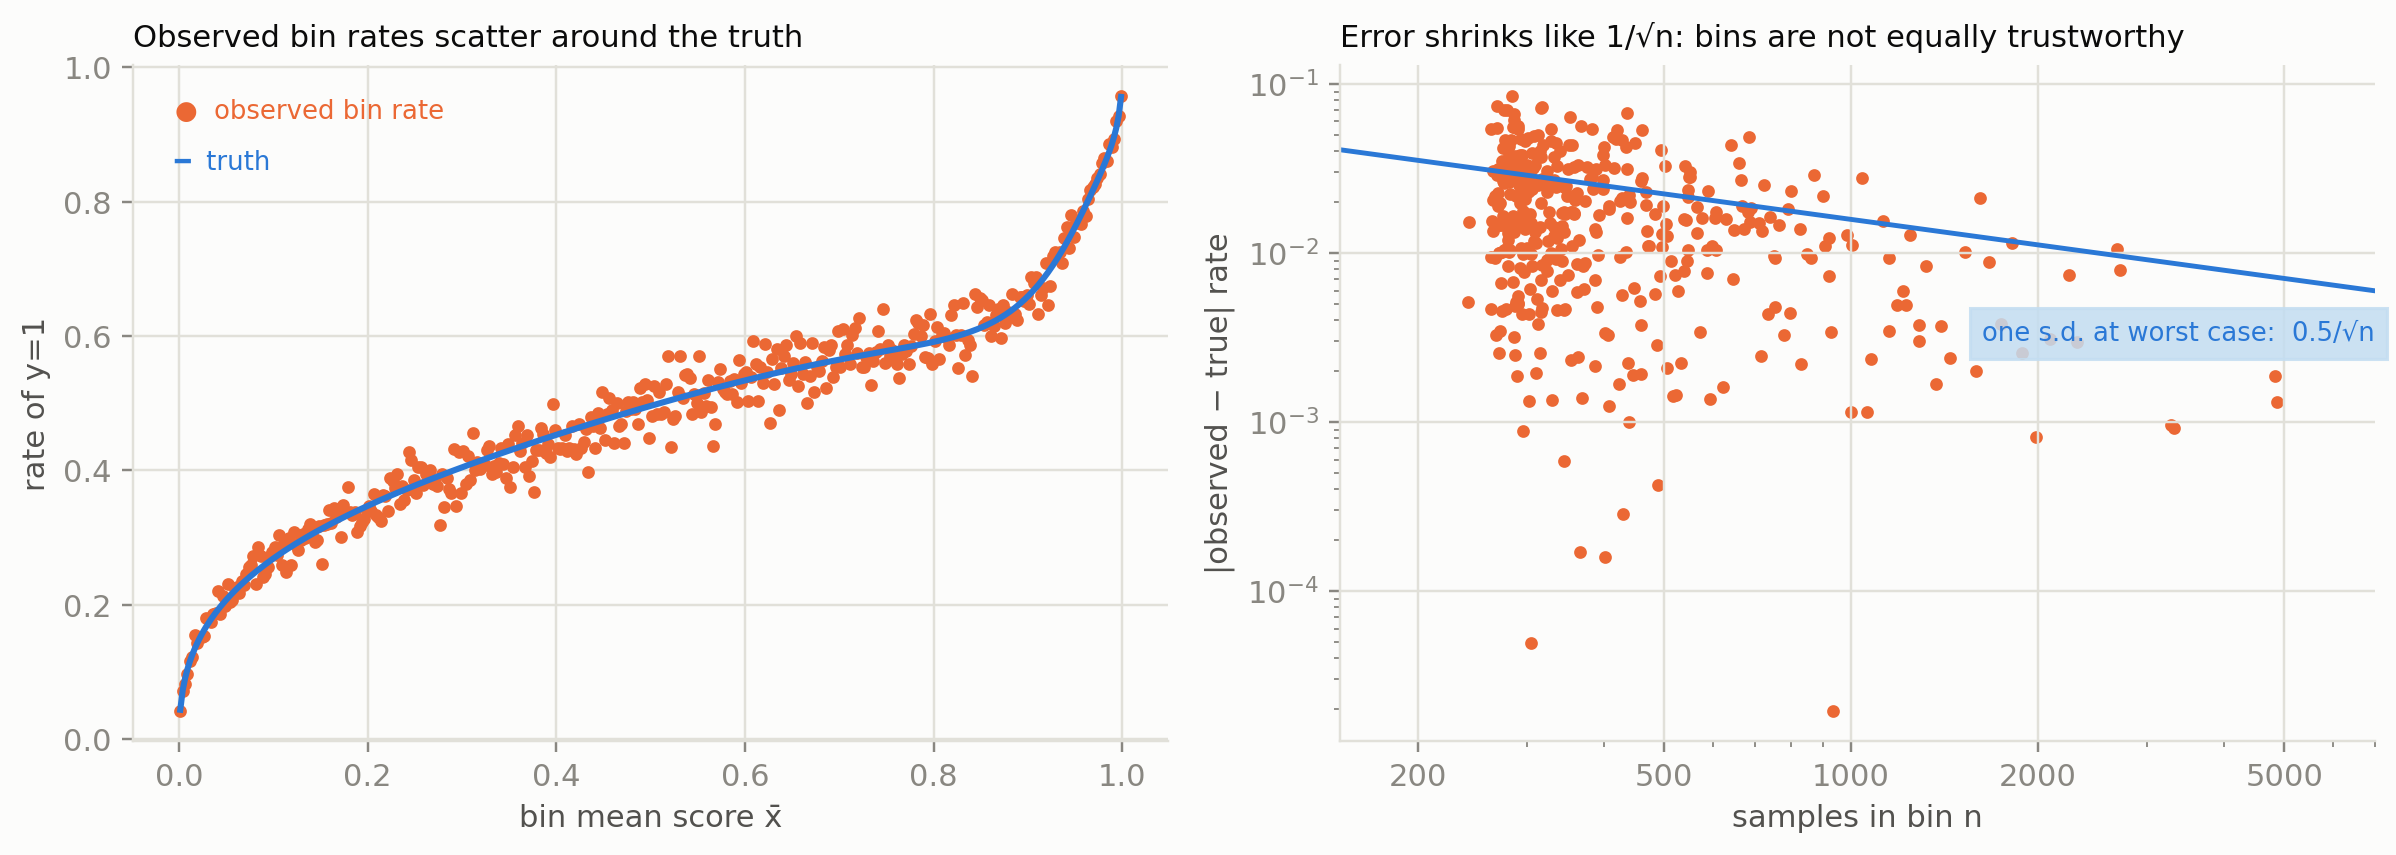

In [47]:
#@title Raw Binned Reliability Diagram and Bin Error Rates

# Why noise-awareness (D6) is needed: per-bin observed rate vs truth, with binomial noise bands
x_bar, rate = sp_b / n_b, sy_b / n_b
ptrue = true_h(x_bar)
se = np.sqrt(ptrue * (1 - ptrue) / n_b)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(x_bar, rate, s=10, color=C["orange"], zorder=3)
ax[0].plot(x_bar, ptrue, color=C["blue"], lw=2, zorder=6)
key(ax[0], [("●  observed bin rate", C["orange"]), ("━  truth", C["blue"])])
ax[0].set_xlabel("bin mean score x̄"); ax[0].set_ylabel("rate of y=1")
ax[0].set_title("Observed bin rates scatter around the truth", loc="left", fontsize=10, color=INK)
ax[1].scatter(n_b, np.abs(rate - ptrue), s=10, color=C["orange"])
nn = np.logspace(np.log10(150), np.log10(7000), 50)
ax[1].plot(nn, 0.5 / np.sqrt(nn), color=C["blue"], lw=1.6)
label(ax[1], nn[-1], 0.5 / np.sqrt(nn[-1]), "one s.d. at worst case:  0.5/√n", C["blue"], dx=0, dy=-14, ha="right", backgroundcolor=(0.765625, 0.8671875, 0.9453125, 0.85))
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_xlim(150, 7000)
ax[1].set_xticks([200, 500, 1000, 2000, 5000]); ax[1].set_xticklabels(["200", "500", "1000", "2000", "5000"])
ax[1].xaxis.set_minor_formatter(plt.NullFormatter())
ax[1].set_xlabel("samples in bin n"); ax[1].set_ylabel("|observed − true| rate")
ax[1].set_title("Error shrinks like 1/√n: bins are not equally trustworthy", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

### D2. Monotonicity by PAV Pooling of *Raw Accumulators*

Enforce $h_1\le h_2\le\dots\le h_K$ with the Pool-Adjacent-Violators algorithm, merging blocks by **adding their $(n,S,P)$ triples**.

**Rationale:** The monotone least-squares problem is
$$\min_{h_1\le\dots\le h_K}\ \sum_b n_b\,(r_b-h_b)^2,\qquad r_b=S_b/n_b .$$
The objective is strictly convex over a convex cone, so the minimiser is unique. At the optimum $h$ is constant on blocks, each block's value must be the *weighted* mean of its members' $r_b$ (else shifting the block lowers the loss without breaking the order), and block values increase. PAV constructs exactly such a partition (Ayer et al., 1955; Barlow et al., 1972). Two consequences:

* **Weighting is automatic.** Adding raw accumulators gives $\frac{S_1+S_2}{n_1+n_2}=\frac{n_1r_1+n_2r_2}{n_1+n_2}$ — the *count-weighted* mean — whereas averaging the two rates would be wrong whenever $n_1\ne n_2$.
* **Same answer for log-loss and Brier\*.** For this problem the isotonic solution is the minimizer for the whole family of Bregman losses (squared error and log-loss included), so the choice of loss does not matter here.

*Suppose every example in bin $b$ gets the same prediction $h_b$. Because $y_i\in\{0,1\}$, we have $y_i^2=y_i$, so the Brier loss summed over that bin's examples is
$$
\begin{aligned}
\sum_{i\in b}(y_i-h_b)^2
&= \sum_{i\in b}y_i^2 \;-\; 2h_b\sum_{i\in b}y_i \;+\; n_b h_b^2 \\
&= S_b - 2h_bS_b + n_b h_b^2 \\
&= n_b\,(r_b-h_b)^2 \;+\; \underbrace{n_b\,r_b(1-r_b)}_{\text{independent of } h_b}.
\end{aligned}
$$
The last line holds because $n_b(r_b-h_b)^2 = n_b r_b^2 - 2h_bS_b + n_b h_b^2$, and $S_b - n_b r_b^2 = n_b r_b(1-r_b)$.
Summing over bins, the weighted least-squares objective $\sum_b n_b(r_b-h_b)^2$ differs from the total Brier loss on the raw examples only by a constant. So the two have the same minimizer under the monotonicity constraint.

**Limitation:** PAV only addresses actual violations: a monotone-but-jagged sequence is left jagged. That is what D3 addresses.

In [34]:
#@title Definitions and Consistency Checks

def pav(sp, sy, n, z=0.0):
    """Stack-based PAV on raw accumulators. z=0 is exactly plain PAV (see D3 for z>0).
    Returns pooled (Σp̂, Σy, n) and, for every input bin, the index of the pool it ended up in."""
    S, Y, N, cnt = [], [], [], []
    for i in range(len(n)):
        S.append(sp[i]); Y.append(sy[i]); N.append(n[i]); cnt.append(1)
        while len(N) >= 2:
            p1, p2 = Y[-2] / N[-2], Y[-1] / N[-1]
            if p1 > p2:
                merge = True
            else:
                pp = (Y[-2] + Y[-1]) / (N[-2] + N[-1])
                se = np.sqrt(max(pp * (1 - pp), 1e-12) * (1 / N[-2] + 1 / N[-1]))
                merge = abs((p2 - p1) / se) < z          # never true when z == 0
            if not merge:
                break
            s, y_, n_, c = S.pop(), Y.pop(), N.pop(), cnt.pop()
            S[-1] += s; Y[-1] += y_; N[-1] += n_; cnt[-1] += c
    return np.array(S), np.array(Y), np.array(N), np.repeat(np.arange(len(N)), cnt)

# (a) hand-checkable example: rates .2 .5 .3 .6 .9  ->  pools .2 .4 .6 .9
_, Y_, N_, _ = pav(np.arange(1., 6.), np.array([2., 5, 3, 6, 9]), np.full(5, 10.))
print("pooled rates:", Y_ / N_, "(expected [0.2 0.4 0.6 0.9])")

# (b) weighting: a 1000-sample bin at 0.5 and a 10-sample bin at 0.3 must pool to the WEIGHTED mean
_, Y_, N_, _ = pav(np.array([500., 3.]), np.array([500., 3.]), np.array([1000., 10.]))
print(f"pooled: {Y_[0]/N_[0]:.4f}   weighted mean: {(500+3)/1010:.4f}   (naive average would be 0.4)")

# (c) cross-check against scikit-learn's isotonic regression on the same bin summaries
S_, Y_, N_, pool_of_bin = pav(sp_b, sy_b, n_b)
ours = (Y_ / N_)[pool_of_bin]
ref = IsotonicRegression().fit(np.arange(len(n_b)), sy_b / n_b, sample_weight=n_b).predict(np.arange(len(n_b)))
print(f"max |ours - sklearn| over {len(n_b)} bins: {np.max(np.abs(ours - ref)):.2e}")
assert np.allclose(ours, ref, atol=1e-12)
print(f"{len(n_b)} bins pooled into {len(N_)} monotone blocks")

pooled rates: [0.2 0.4 0.6 0.9] (expected [0.2 0.4 0.6 0.9])
pooled: 0.4980   weighted mean: 0.4980   (naive average would be 0.4)
max |ours - sklearn| over 400 bins: 0.00e+00
400 bins pooled into 91 monotone blocks


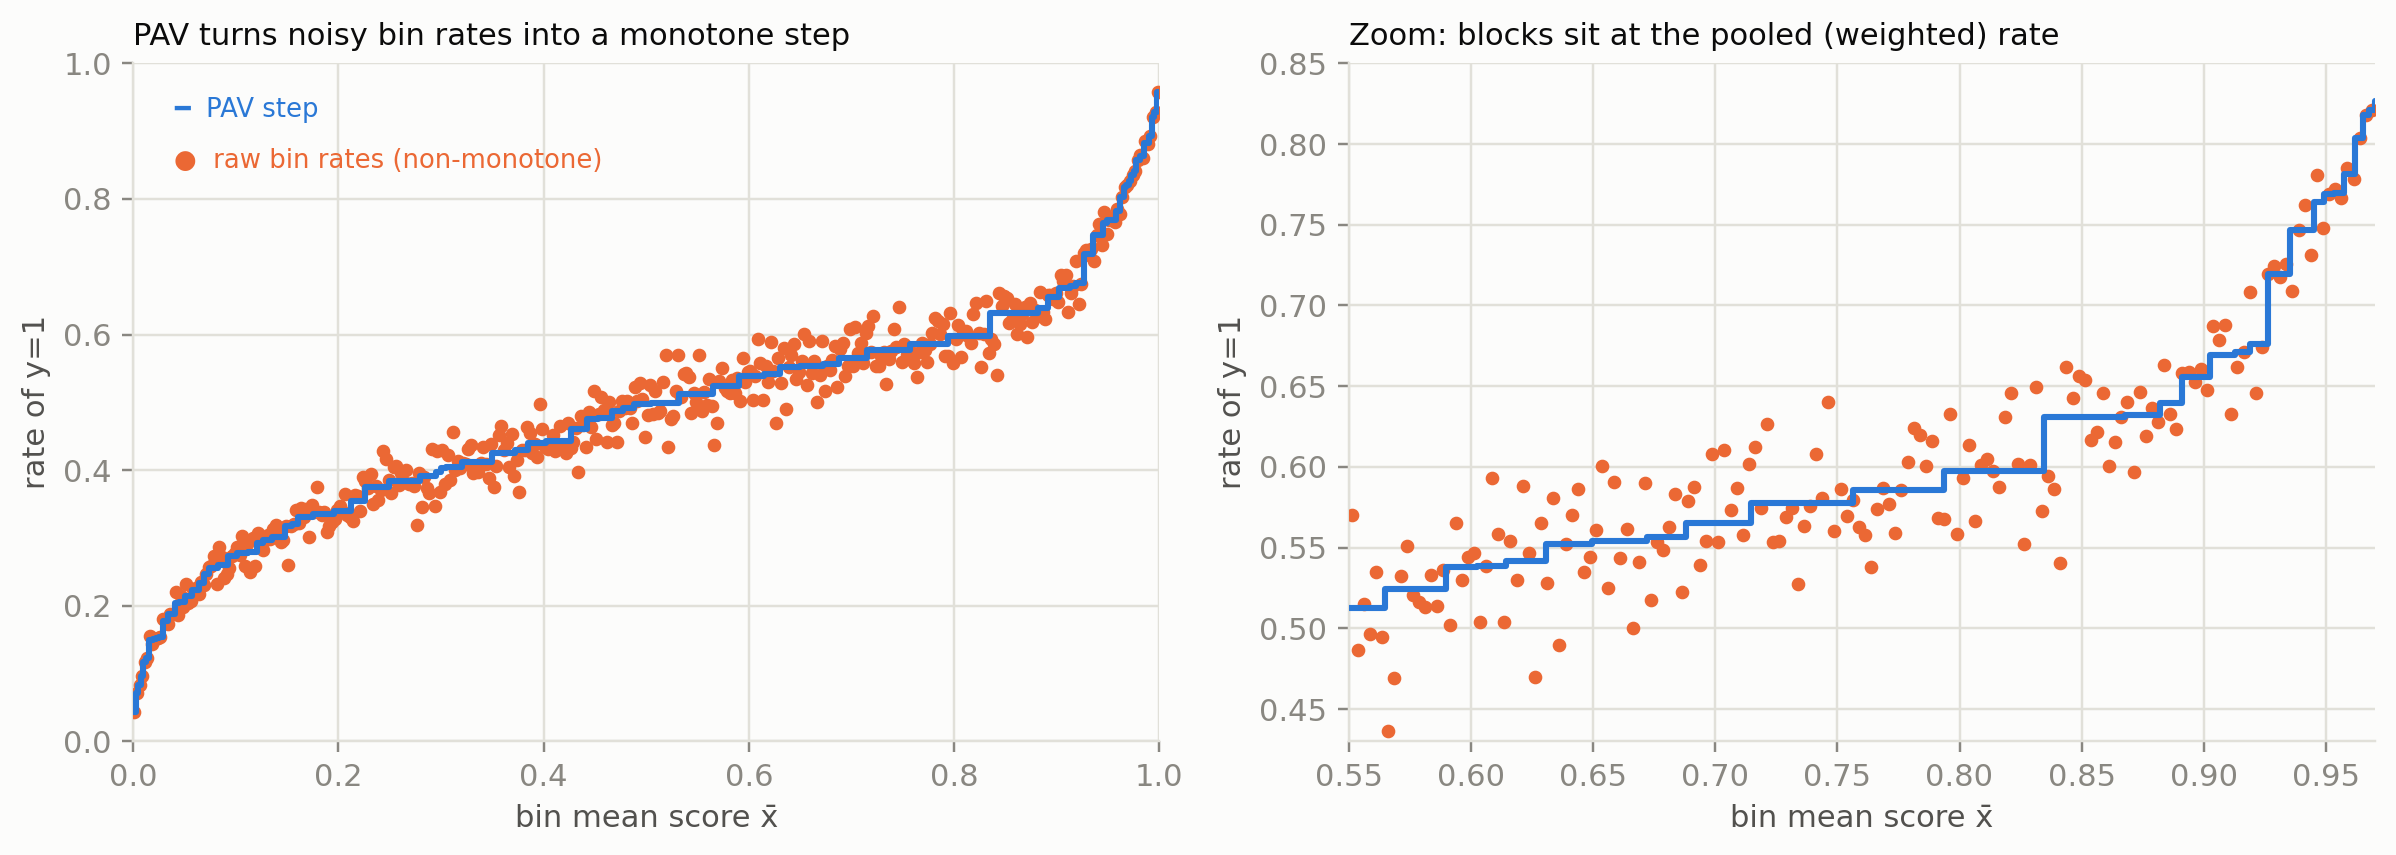

In [40]:
#@title PAV Binned Reliability Diagram with Details

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xk = S_ / N_; yk = Y_ / N_
for a, ((x_bar_lo, x_bar_hi), (rate_lo, rate_hi)) in zip(ax, [((0, 1), (0, 1)), ((0.55, 0.97), (0.43, 0.85))]):
    m = (x_bar >= x_bar_lo) & (x_bar <= x_bar_hi)
    rm = (rate >= rate_lo) & (rate <= rate_hi)
    a.scatter(x_bar[m & rm], rate[m & rm], s=12, color=C["orange"], zorder=3)
    a.step(xk, yk, where="mid", color=C["blue"], lw=2, zorder=6)
    a.set_xlim(x_bar_lo, x_bar_hi)
    a.set_ylim(rate_lo, rate_hi);
    a.set_xlabel("bin mean score x̄"); a.set_ylabel("rate of y=1")
key(ax[0], [("━  PAV step", C["blue"]), ("●  raw bin rates (non-monotone)", C["orange"])])
ax[0].set_title("PAV turns noisy bin rates into a monotone step", loc="left", fontsize=10, color=INK)
ax[1].set_title("Zoom: blocks sit at the pooled (weighted) rate", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

### D3. Optional Significance Merging (`z_threshold`)

After PAV, merge adjacent pools whose observed rates are *statistically indistinguishable*, using a two-proportion $z$-test with pooled variance:
$$z=\frac{r_2-r_1}{\sqrt{\bar r(1-\bar r)\,(1/n_1+1/n_2)}},\qquad \bar r=\frac{S_1+S_2}{n_1+n_2},$$
and merge when $|z|<z^{*}$. With $z^{*}=0$ the test never fires and the algorithm is *exactly* plain PAV.

**Rationale:** Under $H_0$: "both pools share one rate," $\bar r(1-\bar r)(1/n_1+1/n_2)$ is the variance of $r_2-r_1$, so $z$ measures the gap in standard errors. Merging when the gap is within noise trades a little bias for less variance. This effectively acts as a smoothing knob. It is tuned **offline on held-out data**, not selected automatically.

**Limitations:**

* It is a *heuristic*, not a formal test: merges are sequential and cascade, so there is no multiple-testing guarantee.
* The pooled-variance $z$-test assumes **two independent samples**. That holds for bin rates. It does **not** hold for cumulative counts (an empirical CDF), whose consecutive values are *nested* (discussed later).

In [48]:
#@title Definitions

def confidence_weight(rate, count, eps=1e-6):
    """Inverse-variance weight n / (p(1-p)); variance floored at eps (see D6)."""
    return count / np.clip(rate * (1 - rate), eps, None)

def pchip_slopes(x, y, w=None, mode="box_safe", return_info=False):
    """mode: 'unweighted'     classical Fritsch–Butland harmonic mean (ignores w)
             'weighted_naive' confidence-weighted harmonic mean, NO safety cap  (shown to be unsafe in D5)
             'box_safe'       confidence-weighted harmonic mean capped by 3*min(adjacent secants)  <- the method"""
    h = np.diff(x); delta = np.diff(y) / h; m = len(x); d = np.zeros(m)
    if m == 2:
        d[:] = delta[0]
        return (d, 0) if return_info else d
    conf = np.ones(m - 1) if mode == "unweighted" else 2.0 / (1.0 / w[:-1] + 1.0 / w[1:])  # per-secant confidence
    w1 = (2 * h[1:] + h[:-1]) * conf[:-1]
    w2 = (h[1:] + 2 * h[:-1]) * conf[1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        harm = (w1 + w2) / (w1 / delta[:-1] + w2 / delta[1:])
    cap = 3.0 * np.minimum(delta[:-1], delta[1:])
    same = (delta[:-1] * delta[1:]) > 0
    inner = np.minimum(harm, cap) if mode == "box_safe" else harm
    d[1:-1] = np.where(same, inner, 0.0)            # opposite signs or a flat neighbour -> slope 0 (flat segment)
    n_capped = int(np.sum(same & (harm > cap)))
    def edge(h0, h1, d0, d1):                       # shape-preserving three-point end slope
        e = ((2 * h0 + h1) * d0 - h0 * d1) / (h0 + h1)
        if np.sign(e) != np.sign(d0): e = 0.0
        elif np.sign(d0) != np.sign(d1) and abs(e) > 3 * abs(d0): e = 3 * d0
        return e
    d[0] = edge(h[0], h[1], delta[0], delta[1])
    d[-1] = edge(h[-1], h[-2], delta[-1], delta[-2])
    return (d, n_capped) if return_info else d

def pchip_eval(x, y, d, xq, extrap="clamp"):
    """Piecewise cubic Hermite evaluation. extrap='clamp' holds the end values flat (the default
    behaviour); 'tangent' continues the end tangent, clipped to [0,1] (explored in D7)."""
    xq = np.asarray(xq, float)
    xc = np.clip(xq, x[0], x[-1])
    i = np.clip(np.searchsorted(x, xc, side="right") - 1, 0, len(x) - 2)
    x0, x1, y0, y1, d0, d1 = x[i], x[i + 1], y[i], y[i + 1], d[i], d[i + 1]
    h = x1 - x0; t = (xc - x0) / h; t2, t3 = t * t, t * t * t
    out = (2*t3 - 3*t2 + 1) * y0 + (t3 - 2*t2 + t) * h * d0 + (-2*t3 + 3*t2) * y1 + (t3 - t2) * h * d1
    if extrap == "tangent":
        out = np.where(xq < x[0], np.clip(y[0] + d[0] * (xq - x[0]), 0, 1), out)
        out = np.where(xq > x[-1], np.clip(y[-1] + d[-1] * (xq - x[-1]), 0, 1), out)
    return out

def fit_curve(sp, sy, n, z=0.0, mode="box_safe", anchor=False):
    """Bins -> PAV -> knots -> slopes. Knots sit at each pool's MEAN score and observed rate."""
    S, Y, N, pool_of_bin = pav(sp, sy, n, z)
    x, y, w = S / N, Y / N, N.copy()
    pool_rate = y.copy()
    if anchor:                                       # forced (0,0) and (1,1): see D7 for why this is NOT the default
        x = np.r_[0.0, x, 1.0]; y = np.r_[0.0, y, 1.0]; w = np.r_[w[0], w, w[-1]]
        if x[1] == x[0]: x[1] += 1e-9
        if x[-2] == x[-1]: x[-2] -= 1e-9
    d = pchip_slopes(x, y, confidence_weight(y, w), mode)
    return dict(x=x, y=y, d=d, w=w, pool_of_bin=pool_of_bin, pool_rate=pool_rate, n_pools=len(N))

In [49]:
#@title Example `z_threshold` Scan

# z_threshold is a bias/variance knob: tune on held-out data, and judge differences with PAIRED standard errors
base = fit_curve(sp_b, sy_b, n_b, z=0.0)
out0 = pchip_eval(base["x"], base["y"], base["d"], p_va)
rows = []
for z in [0.0, 1.0, 1.5, 2.0, 3.0]:
    f = fit_curve(sp_b, sy_b, n_b, z=z)
    o = pchip_eval(f["x"], f["y"], f["d"], p_va)
    db, sb = paired(brier_each(o, y_va), brier_each(out0, y_va))
    dl, sl = paired(logloss_each(o, y_va), logloss_each(out0, y_va))
    rows.append(dict(z=z, pools=f["n_pools"], ECE15=ece(o, y_va, 15), ECE100=ece(o, y_va, 100),
                     dBrier_vs_z0=f"{db:+.2e} ± {sb:.1e}", dLogLoss_vs_z0=f"{dl:+.2e} ± {sl:.1e}"))
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.5f}"))

      z  pools   ECE15  ECE100        dBrier_vs_z0      dLogLoss_vs_z0
0.00000     91 0.00515 0.01106 +0.00e+00 ± 0.0e+00 +0.00e+00 ± 0.0e+00
1.00000     39 0.00553 0.01122 +2.79e-06 ± 1.2e-05 +5.35e-06 ± 2.9e-05
1.50000     29 0.00573 0.01092 -3.89e-06 ± 1.2e-05 -5.77e-07 ± 3.4e-05
2.00000     24 0.00496 0.01050 -8.05e-06 ± 1.3e-05 -5.07e-06 ± 3.6e-05
3.00000     16 0.00591 0.01078 +2.33e-06 ± 1.9e-05 +6.22e-06 ± 4.7e-05


**Reading the table:** Raising $z$ collapses 91 pools to 16, yet no held-out difference in Brier or log-loss is significant, and ECE moves non-monotonically within noise. On this problem the extra smoothing is therefore *free* but *unproven*: treat $z$ as a simplicity knob unless held-out data on your own problem show a real gain.

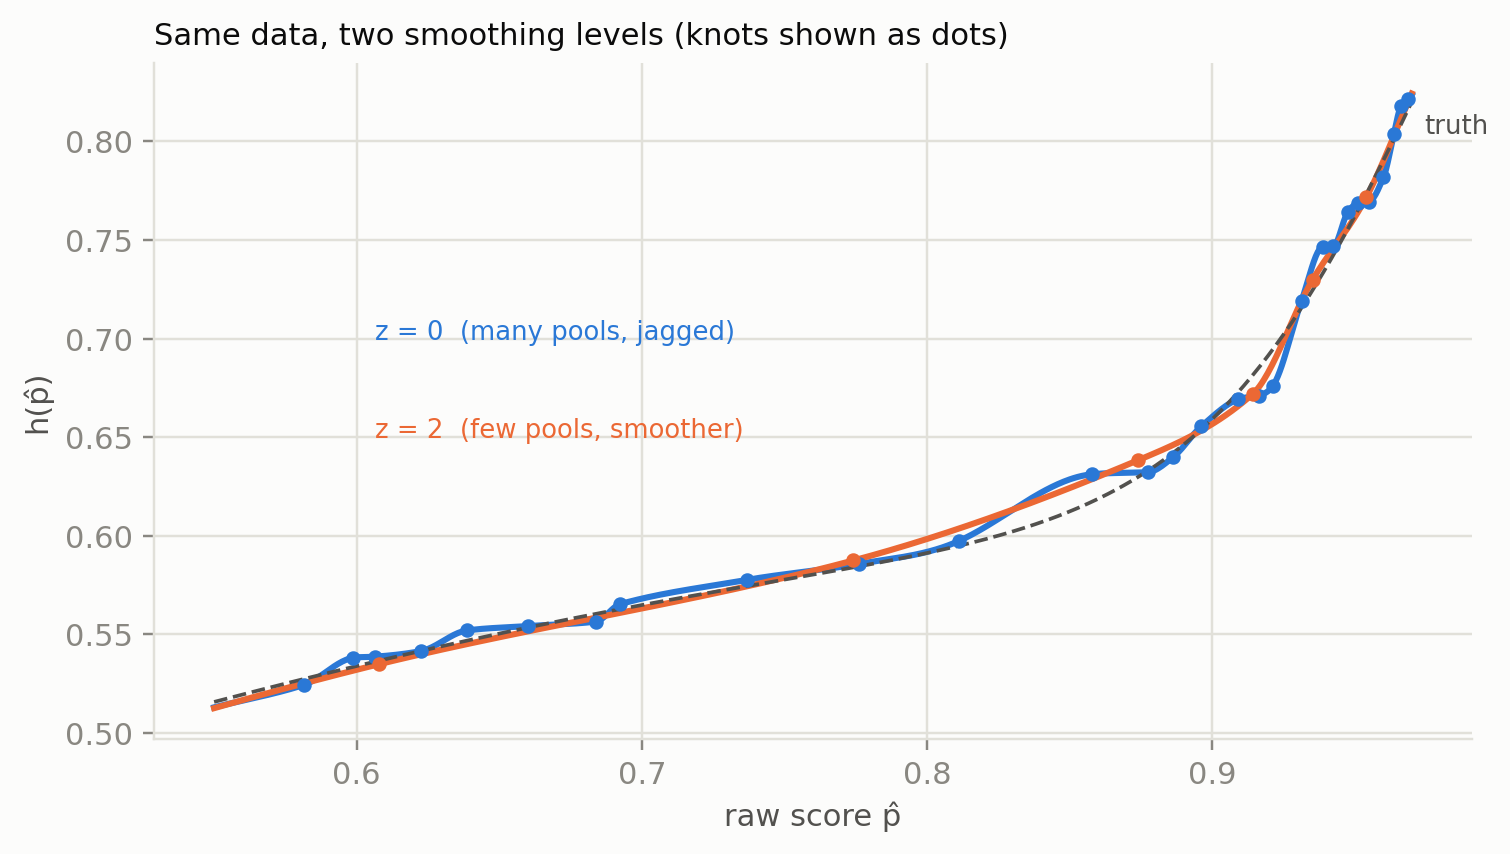

In [51]:
#@title Reliability Diagram Detail (`z_threshold`)

fig, ax = plt.subplots(figsize=(7, 4))
for z, col, ls in [(0.0, C["blue"], "-"), (2.0, C["orange"], "-")]:
    f = fit_curve(sp_b, sy_b, n_b, z=z)
    gg = np.linspace(0.55, 0.97, 600)
    ax.plot(gg, pchip_eval(f["x"], f["y"], f["d"], gg), color=col, lw=2, ls=ls)
    m = (f["x"] > 0.55) & (f["x"] < 0.97)
    ax.scatter(f["x"][m], f["y"][m], s=14, color=col, zorder=3)
ax.plot(gg, true_h(gg), color=INK2, lw=1.2, ls="--")
label(ax, 0.97, true_h(np.array([0.97]))[0], "truth", INK2, dx=4, dy=-8)
label(ax, 0.60, 0.74, "z = 0  (many pools, jagged)", C["blue"], dy=-24)
label(ax, 0.60, 0.70, "z = 2  (few pools, smoother)", C["orange"], dy=-30)
ax.set_xlabel("raw score p̂")
ax.set_ylabel("h(p̂)")
ax.set_title("Same data, two smoothing levels (knots shown as dots)", loc="left", fontsize=10, color=INK)
plt.tight_layout()
plt.show()

### D4. Interpolate the Pooled Knots with PCHIP

The pooled knots $(\bar x_k,\bar y_k)$ are joined by a [**piecewise cubic Hermite**](https://en.wikipedia.org/wiki/Cubic_Hermite_spline#Interpolation_on_an_arbitrary_interval) interpolant. On $[x_k,x_{k+1}]$, with $h_k=x_{k+1}-x_k$, $t=(x-x_k)/h_k$, and endpoint slopes $d_k,d_{k+1}$,
$$H(x)=h_{00}(t)\,y_k+h_{10}(t)\,h_k\,d_k+h_{01}(t)\,y_{k+1}+h_{11}(t)\,h_k\,d_{k+1},$$
with the cubic Hermite basis $h_{00}=2t^3-3t^2+1$, $h_{10}=t^3-2t^2+t$, $h_{01}=-2t^3+3t^2$, $h_{11}=t^3-t^2$ (Fritsch & Carlson, 1980).

**Rationale** A step function is non-injective as every score in a pool gets *one* output, so ties appear. ROC AUC depends only on the rank order of scores, so for a **strictly increasing** map $h$ we have $\mathrm{AUC}(h\circ s)=\mathrm{AUC}(s)$ exactly. Introducing ties breaks that invariance (and also breaks threshold-based downstream logic that expects distinct scores to stay distinct).

Why PCHIP rather than the alternatives?

| interpolant | monotone? | smooth? | local? |
|---|---|---|---|
| step (PAV output) | yes | no (jumps) | yes, but **ties** |
| linear between knots | yes | $C^0$ only (slope jumps at knots) | yes |
| cubic spline | not guaranteed | $C^2$ | no (global solve) |
| **PCHIP** | **yes (D5)** | $C^1$ | yes |

**Tradeoffs and Limitations**

* Linear interpolation is *also* monotone and tie-free. PCHIP's advantage over it is smoothness ($C^1$), not monotonicity; and a smooth interpolant is not an exact conditional mean in between knots, which leaves a small in-sample residual (Section 9).
* "Strictly increasing" has two exceptions, both visible in the table below:
  1. **Beyond the end knots.** Without anchors (D7), scores outside $[x_{\text{first}},x_{\text{last}}]$ are clamped to one value each, which introduces ties. Continuing the end tangent instead (D7) removes them.
  2. **Exactly equal neighbouring rates.** PAV only merges *strict* violations ($r_1>r_2$), so two adjacent pools with identical rates stay separate; the slope there is $0$ and PCHIP draws a flat plateau between them. This is rare, but with discrete counts it happens (the cell below finds a pair with 123/286 positives each). Any `z_threshold>0` merges such a pair, since $z=0<z^{*}$.

In [52]:
#@title Definitions and Consistency Checks

def step_apply(p, fit, n_bins, kept_bins):
    """PAV step function: each score gets the rate of the pool its fit-bin belongs to."""
    rate_bin = np.full(n_bins, np.nan)
    rate_bin[kept_bins] = fit["pool_rate"][fit["pool_of_bin"]]
    ok = ~np.isnan(rate_bin)                                  # bins empty in training: borrow nearest filled bin
    rate_bin = np.interp(np.arange(n_bins), np.flatnonzero(ok), rate_bin[ok])
    return rate_bin[np.minimum((np.clip(p, 0, 1) * n_bins).astype(np.int64), n_bins - 1)]

fit = base
cs = CubicSpline(fit["x"], fit["pool_rate"])
cands = {
    "raw score":          p_va,
    "PAV step":           step_apply(p_va, fit, N_BINS, bin_idx),
    "linear interp":      np.interp(p_va, fit["x"], fit["y"]),
    "cubic spline":       np.clip(cs(np.clip(p_va, fit["x"][0], fit["x"][-1])), 0, 1),
    "PCHIP (this method)": out0,
}
cands["PCHIP + tangent ends"] = pchip_eval(fit["x"], fit["y"], fit["d"], p_va, "tangent")
rows = [dict(method=k, ROC_AUC=roc_auc_score(y_va, v), unique_outputs=len(np.unique(v))) for k, v in cands.items()]
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.6f}"))

# PCHIP is strictly increasing between the first and last knot, so where do its ties come from?
n_lo, n_hi = int(np.sum(p_va < fit["x"][0])), int(np.sum(p_va > fit["x"][-1]))
print(f"\nvalidation scores below the first knot: {n_lo}, above the last knot: {n_hi}  "
      f"(all clamped to one value each)")
print(f"ties explained by the flat clamp: {max(n_lo-1,0) + max(n_hi-1,0)}   "
      f"actual ties: {len(p_va) - len(np.unique(cands['PCHIP (this method)']))}")

# the remaining ties: adjacent pools whose observed rates are EXACTLY equal (PAV only merges strict violations)
eq = np.flatnonzero(np.diff(fit["pool_rate"]) == 0)
for k in eq:
    lo_, hi_ = fit["x"][k], fit["x"][k + 1]
    m = (p_va > lo_) & (p_va < hi_)
    print(f"pools {k} and {k+1} have identical rate {fit['pool_rate'][k]:.5f}; the flat plateau between them "
          f"spans p in [{lo_:.4f}, {hi_:.4f}] and contains {int(m.sum())} validation scores")
print("with tangent ends, remaining ties are only those plateaus:",
      len(p_va) - len(np.unique(cands["PCHIP + tangent ends"])))
gfine = np.linspace(fit["x"][0], fit["x"][-1], 40001)
print("\nmonotonicity violations on a fine grid  (count of decreasing steps):")
print("  cubic spline :", int(np.sum(np.diff(cs(gfine)) < -1e-12)))
print("  PCHIP        :", int(np.sum(np.diff(pchip_eval(fit['x'], fit['y'], fit['d'], gfine)) < -1e-12)))
print("  linear       :", int(np.sum(np.diff(np.interp(gfine, fit['x'], fit['y'])) < -1e-12)))

              method  ROC_AUC  unique_outputs
           raw score 0.779525           90000
            PAV step 0.779366              90
       linear interp 0.779521           87729
        cubic spline 0.779488           87870
 PCHIP (this method) 0.779521           87731
PCHIP + tangent ends 0.779525           89861

validation scores below the first knot: 1034, above the last knot: 1098  (all clamped to one value each)
ties explained by the flat clamp: 2130   actual ties: 2269
pools 41 and 42 have identical rate 0.43007; the flat plateau between them spans p in [0.3787, 0.3813] and contains 142 validation scores
with tangent ends, remaining ties are only those plateaus: 139

monotonicity violations on a fine grid  (count of decreasing steps):
  cubic spline : 5020
  PCHIP        : 0
  linear       : 0


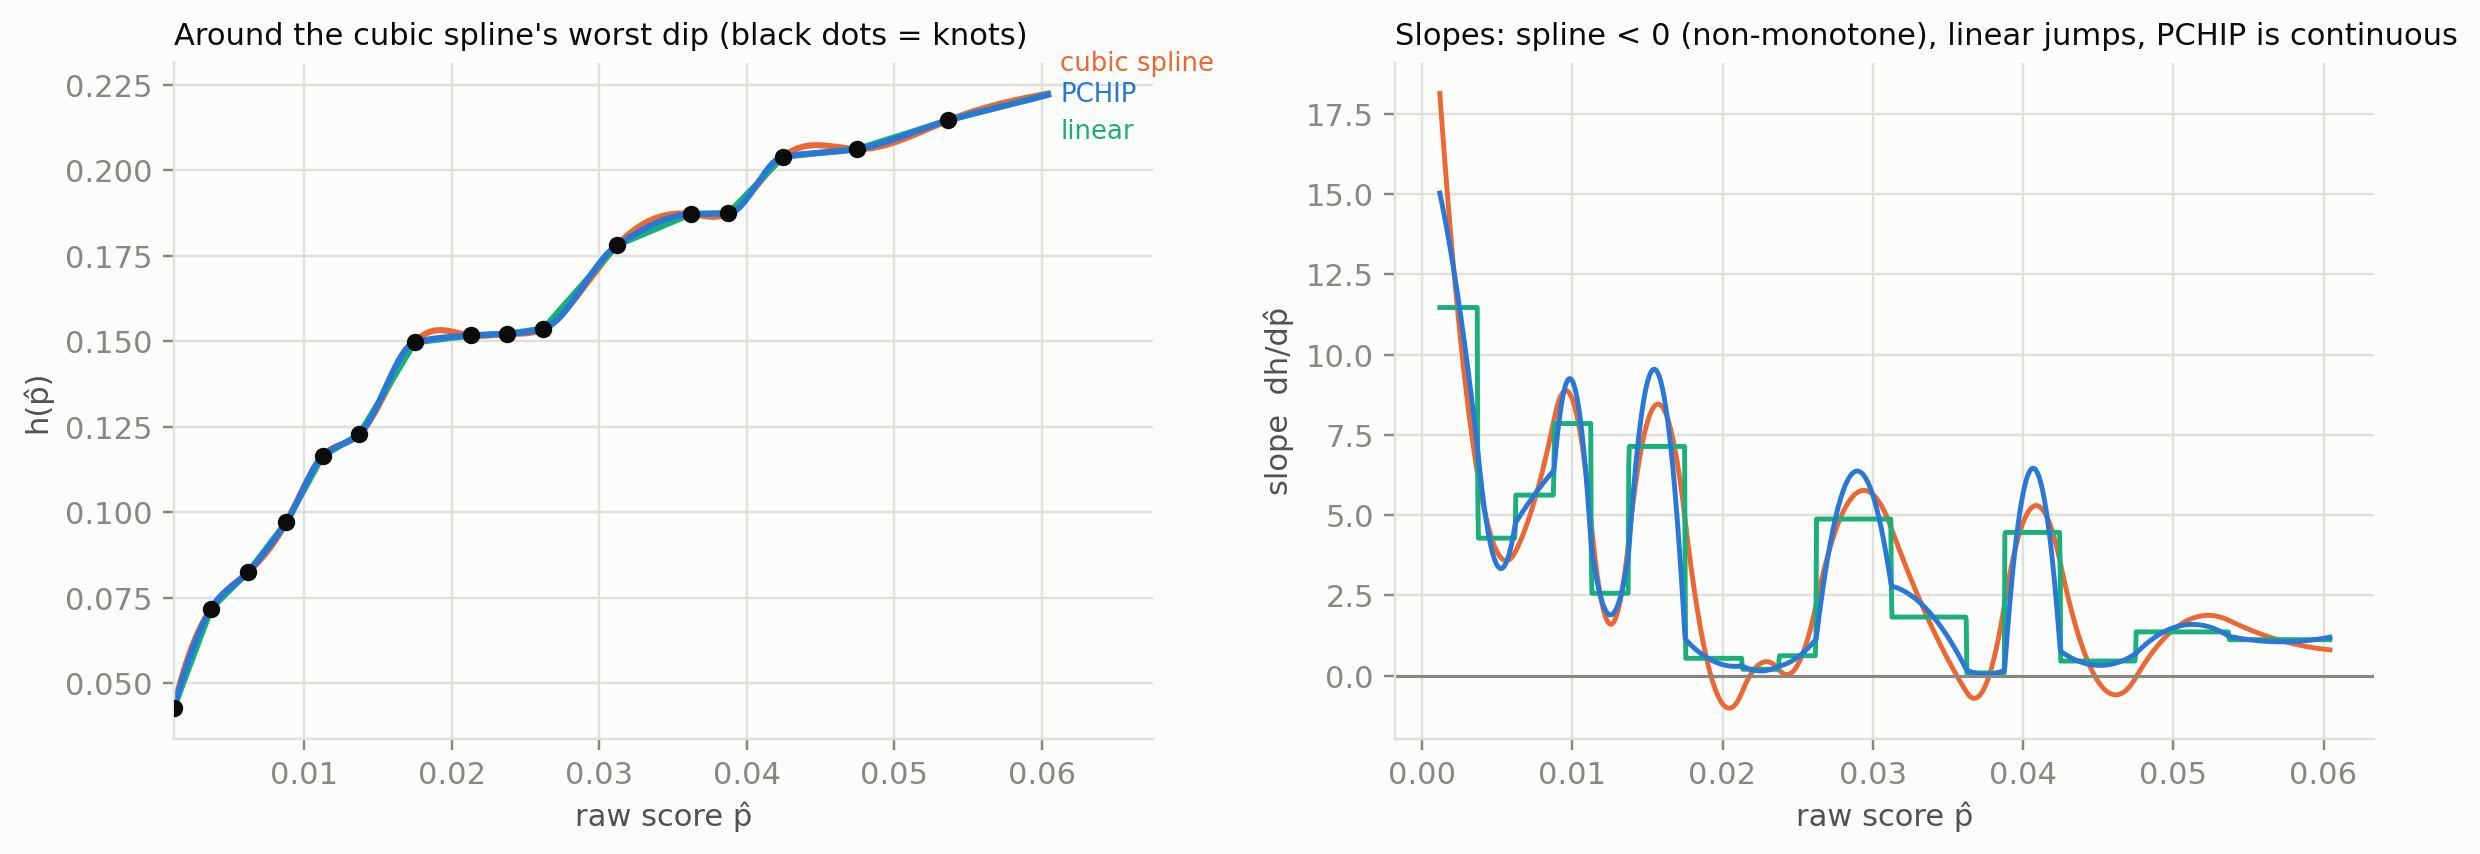

In [53]:
#@title Interpolation Comparisons

# Visualise: where does the cubic spline break monotonicity, and how do the others look there?
dcs = np.diff(cs(gfine))
if np.any(dcs < 0):
    centre = gfine[np.argmin(dcs)]
else:
    centre = fit["x"][1 + np.argmax(np.abs(np.diff(fit["d"][1:-1])))]   # fallback: where the slope changes most
lo, hi = centre - 0.04, centre + 0.04
gg = np.linspace(max(lo, fit["x"][0]), min(hi, fit["x"][-1]), 1500)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
curves = [("cubic spline", cs(gg), C["orange"]), ("linear", np.interp(gg, fit["x"], fit["y"]), C["aqua"]),
          ("PCHIP", pchip_eval(fit["x"], fit["y"], fit["d"], gg), C["blue"])]
for name, v, col in curves:
    ax[0].plot(gg, v, color=col, lw=2)
m = (fit["x"] >= gg[0]) & (fit["x"] <= gg[-1])
ax[0].scatter(fit["x"][m], fit["y"][m], s=22, color=INK, zorder=4)
ax[0].set_xlabel("raw score p̂")
ax[0].set_ylabel("h(p̂)")
ax[0].set_title("Around the cubic spline's worst dip (black dots = knots)", loc="left", fontsize=10, color=INK)
for (name, v, col), dy in zip(curves, [10, -12, 0]):
    label(ax[0], gg[-1], v[-1], name, col, dx=4, dy=dy)
ax[0].set_xlim(gg[0], gg[-1] + 0.02 * (gg[-1] - gg[0]) * 6)
for name, v, col in curves:
    ax[1].plot(gg[1:], np.diff(v) / np.diff(gg), color=col, lw=1.6)
ax[1].axhline(0, color=MUTED, lw=1)
ax[1].set_xlabel("raw score p̂")
ax[1].set_ylabel("slope  dh/dp̂")
ax[1].set_title("Slopes: spline < 0 (non-monotone), linear jumps, PCHIP is continuous", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

### D5. Box-Safe Slopes: Guaranteed Monotonicity With Weighted Data

D6 introduces confidence-weighted data.
PCHIP doesn't natively support differently-weighted data, so additional constraints on the slopes must be derived here.

#### The monotonicity region of a Hermite cubic

On one segment let $\delta_k=(y_{k+1}-y_k)/h_k>0$ be the secant slope and define $\alpha=d_k/\delta_k$, $\beta=d_{k+1}/\delta_k$. Differentiating the Hermite form gives
$$\frac{1}{h_k\delta_k}\frac{dH}{dt}=g(t)=6t(1-t)+\alpha\,(3t^2-4t+1)+\beta\,(3t^2-2t),\qquad g(0)=\alpha,\; g(1)=\beta.$$
$H$ is monotone on the segment iff $g\ge0$ on $[0,1]$. Fritsch & Carlson (1980) characterise the exact region; a simple **sufficient** condition is the box
$$\boxed{\;0\le\alpha\le3,\quad 0\le\beta\le3\;}$$
Both slopes at a knot touch two segments, so what we need is a slope $d_k$ that is inside the box for **both** neighbours at once: $d_k\le3\,\delta_{k-1}$ **and** $d_k\le3\,\delta_k$, i.e.
$$d_k\ \le\ 3\min(\delta_{k-1},\delta_k).$$

#### Why the classical harmonic mean is already safe and why confidence weights break it

The classical (Fritsch–Butland) slope is a weighted harmonic mean
$$d_k=\Big(\tfrac{\lambda}{\delta_{k-1}}+\tfrac{1-\lambda}{\delta_k}\Big)^{-1},\qquad \lambda=\frac{2h_k+h_{k-1}}{3(h_k+h_{k-1})}\in\big(\tfrac13,\tfrac23\big).$$
Because $\lambda>\tfrac13$ and $1-\lambda>\tfrac13$, we get $d_k<\delta_{k-1}/\lambda<3\delta_{k-1}$ and likewise $d_k<3\delta_k$: **the spacing weights alone keep $d_k$ inside the box.**

Confidence weighting (D6) multiplies the two terms by *data-dependent* confidences, which stretches $\lambda$ over all of $(0,1)$. If the right-hand secant is far more trustworthy, $\lambda\to0$ and $d_k\to\delta_k$ — which can exceed $3\delta_{k-1}$ when $\delta_k>3\delta_{k-1}$. The box is breached and the left segment can go non-monotone.

#### The fix is a one-line `min`

$$\boxed{\;d_k=\min\!\Big(\text{confidence-weighted harmonic mean of }\delta_{k-1},\delta_k,\;\;3\min(\delta_{k-1},\delta_k)\Big)\;}$$

Monotonicity of every segment now follows *algebraically* from $d_k\le3\min(\cdot)$. If $\delta_{k-1}\delta_k\le0$ (a sign change or a flat neighbour) we set $d_k=0$, which forces a flat spot there.

every (α,β) in the box [0,3]² is monotone      : True
share of the box area that is monotone         : 1.000
monotone points OUTSIDE the box (sufficient, not necessary): 42272


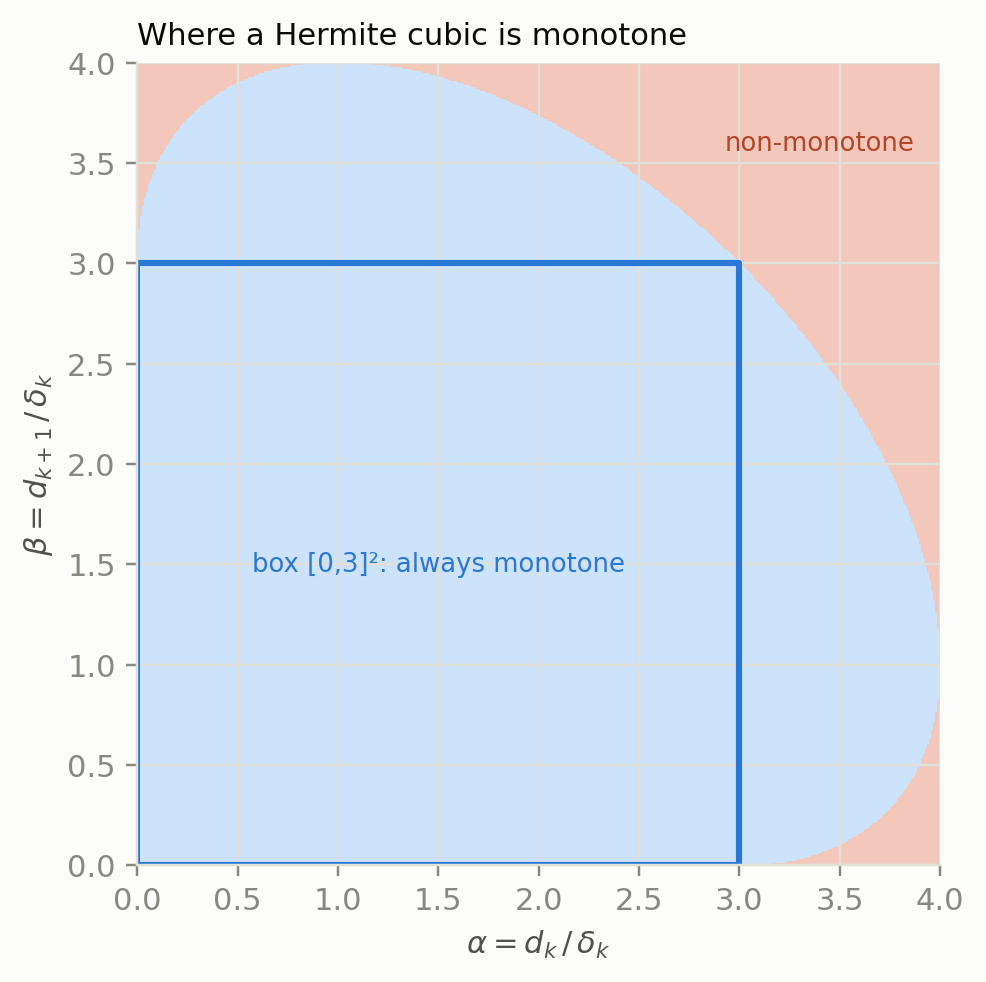

In [57]:
#@title Monotonicity Region

# (1) Verify the monotonicity region numerically: g(t) >= 0 on [0,1]?
t = np.linspace(0, 1, 101)[:, None, None]
a = np.linspace(0, 4, 401)[None, :, None]; b = np.linspace(0, 4, 401)[None, None, :]
gmin = (6*t*(1-t) + a*(3*t**2 - 4*t + 1) + b*(3*t**2 - 2*t)).min(axis=0)       # (alpha, beta) grid
mono = gmin >= -1e-12
A, B = np.meshgrid(a.ravel(), b.ravel(), indexing="ij")
in_box = (A <= 3) & (B <= 3)
print("every (α,β) in the box [0,3]² is monotone      :", bool(mono[in_box].all()))
print(f"share of the box area that is monotone         : {mono[in_box].mean():.3f}")
print(f"monotone points OUTSIDE the box (sufficient, not necessary): {int(mono[~in_box].sum())}")
assert mono[in_box].all()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.contourf(a.ravel(), b.ravel(), mono.T, levels=[-0.5, 0.5, 1.5], colors=["#f4c7bb", "#cde2fb"])
ax.plot([0, 3, 3, 0, 0], [0, 0, 3, 3, 0], color=C["blue"], lw=2)
label(ax, 1.5, 1.5, "box [0,3]²: always monotone", C["blue"], dx=0, ha="center")
label(ax, 3.4, 3.6, "non-monotone", "#b3452a", dx=0, ha="center")
ax.set_xlabel(r"$\alpha = d_k\,/\,\delta_k$")
ax.set_ylabel(r"$\beta = d_{k+1}\,/\,\delta_k$")
ax.set_aspect("equal")
ax.set_title("Where a Hermite cubic is monotone", loc="left", fontsize=10, color=INK)
plt.tight_layout()
plt.show()

In [58]:
#@title Consistency Check with `scipy.PchipInterpolator`

# (2) Cross-check the unweighted slopes + evaluation against SciPy's PCHIP
rng = np.random.default_rng(3)
xt = np.r_[0.0, np.sort(rng.uniform(0, 1, 15)), 1.0]; yt = np.sort(rng.uniform(0, 1, len(xt)))
xq = np.linspace(0, 1, 5001)
ours = pchip_eval(xt, yt, pchip_slopes(xt, yt, mode="unweighted"), xq)
print("max |ours - scipy.PchipInterpolator| (unweighted case):", np.max(np.abs(ours - PchipInterpolator(xt, yt)(xq))))
assert np.allclose(ours, PchipInterpolator(xt, yt)(xq), atol=1e-12)

# (3) Stress test: random knots, weights spanning FIVE orders of magnitude; count non-monotone segments
def seg_monotone(y0, y1, d0, d1, h, npts=60):
    t = np.linspace(0, 1, npts)
    v = (2*t**3 - 3*t**2 + 1)*y0 + (t**3 - 2*t**2 + t)*h*d0 + (-2*t**3 + 3*t**2)*y1 + (t**3 - t**2)*h*d1
    return np.all(np.diff(v) >= -1e-9)

def stress(mode, trials=4000, seed=0):
    rng = np.random.default_rng(seed); bad = segs = 0
    for _ in range(trials):
        xs = np.unique(np.sort(rng.uniform(0, 1, rng.integers(4, 10))))
        if len(xs) < 4: continue
        ys = np.sort(rng.uniform(0, 1, len(xs))); ws = 10 ** rng.uniform(0, 5, len(xs))
        d = pchip_slopes(xs, ys, ws, mode)
        for i in range(len(xs) - 1):
            segs += 1
            bad += not seg_monotone(ys[i], ys[i+1], d[i], d[i+1], xs[i+1] - xs[i])
    return bad, segs

for mode in ["unweighted", "weighted_naive", "box_safe"]:
    bad, segs = stress(mode)
    print(f"{mode:15s}: {bad:5d} non-monotone segments out of {segs}")

max |ours - scipy.PchipInterpolator| (unweighted case): 3.3306690738754696e-16
unweighted     :     0 non-monotone segments out of 21962
weighted_naive :  2701 non-monotone segments out of 21962
box_safe       :     0 non-monotone segments out of 21962


In [59]:
#@title Test Cases

# (4) A concrete counterexample for the naive weighting, and how often the cap binds on real data
x3 = np.array([0.0, 1.0, 2.0]); y3 = np.array([0.0, 1.0, 11.0])        # secants δ = 1 then 10
w3 = np.array([1.0, 1e4, 1e4])                                          # right-hand knots far more trustworthy
for mode in ["weighted_naive", "box_safe"]:
    d3 = pchip_slopes(x3, y3, w3, mode)
    ok = seg_monotone(y3[0], y3[1], d3[0], d3[1], 1.0)
    print(f"{mode:15s}: d_1 = {d3[1]:6.3f}  (3·min δ = 3.000)  left segment monotone: {ok}")

d_, n_cap = pchip_slopes(base["x"], base["y"], confidence_weight(base["y"], base["w"]), "box_safe", return_info=True)
print(f"\non the real fit: cap binds at {n_cap} of {len(base['x']) - 2} interior knots "
      f"({100 * n_cap / (len(base['x']) - 2):.1f}%) (not the common case)")

weighted_naive : d_1 =  9.982  (3·min δ = 3.000)  left segment monotone: False
box_safe       : d_1 =  3.000  (3·min δ = 3.000)  left segment monotone: True

on the real fit: cap binds at 1 of 89 interior knots (1.1%) (not the common case)


### D6. Inverse-variance confidence weights

A secant's confidence is the harmonic mean of its two endpoint weights. Each pool's rate $\hat p_k=S_k/n_k$ gets weight $w_k=n_k/\max\{\hat p_k(1-\hat p_k),\varepsilon\}$.

**Rationale:** For a Bernoulli sample proportion, $\operatorname{Var}(\hat p_k)\approx\hat p_k(1-\hat p_k)/n_k$, so $w_k$ is the **precision** (inverse variance). The slope of a secant is a difference of two independent estimates, whose variance is $\operatorname{Var}_k+\operatorname{Var}_{k+1}$ (up to $1/h^2$), so its precision is $\big(1/w_k+1/w_{k+1}\big)^{-1}$ (a harmonic combination). The code uses $2/(1/w_k+1/w_{k+1})$; the constant 2 cancels because only *relative* secant weights matter in the weighted harmonic mean. The floor $\varepsilon$ keeps the weight finite when a pool's observed rate is exactly 0 or 1.

The resulting effect is that a pool with few samples or an extreme variance contributes a noisy knot. Weighting makes the slopes at *neighboring* knots lean on the better-measured secant.

**Tradeoffs:** The weight uses the *estimated* rate in its own variance, which is itself noisy for small pools; and the `min` cap (D5) is needed *because* of this weighting.

In [60]:
#@title Simulated Weighted Data Profile

# Monte Carlo: does confidence weighting reduce error against the ground truth? (paired over 30 seeds)
p_eval, _ = make_data(100_000, seed=999)
t_eval = true_h(p_eval)
def rmse_vs_truth(f, extrap="clamp"):
    return np.sqrt(np.mean((pchip_eval(f["x"], f["y"], f["d"], p_eval, extrap) - t_eval) ** 2))

res = {"unweighted": [], "weighted_naive": [], "box_safe": []}
viol = {k: 0 for k in res}                     # non-monotone fine-grid steps, summed over all realistic fits
for seed in range(30):
    p_, y_ = make_data(60_000, seed=100 + seed)
    spk, syk, nk, _ = finalize(accumulate(p_, y_, N_BINS))
    for mode in res:
        f_ = fit_curve(spk, syk, nk, mode=mode)
        res[mode].append(rmse_vs_truth(f_))
        gg_ = np.linspace(f_["x"][0], f_["x"][-1], 20001)
        viol[mode] += int(np.sum(np.diff(pchip_eval(f_["x"], f_["y"], f_["d"], gg_)) < -1e-12))
res = {k: np.array(v) for k, v in res.items()}
print("non-monotone steps on realistic fits (30 fits, 20,000-point grid each):", viol)
for mode, v in res.items():
    print(f"{mode:15s} RMSE vs truth: {v.mean():.5f}  (± {v.std(ddof=1)/np.sqrt(len(v)):.5f} s.e. over {len(v)} seeds)")
for mode in ["weighted_naive", "box_safe"]:
    d = res[mode] - res["unweighted"]
    print(f"paired diff ({mode} - unweighted): {d.mean():+.6f} ± {d.std(ddof=1)/np.sqrt(len(d)):.6f}   "
          f"better in {int((d < 0).sum())}/{len(d)} seeds")

non-monotone steps on realistic fits (30 fits, 20,000-point grid each): {'unweighted': 0, 'weighted_naive': 530, 'box_safe': 0}
unweighted      RMSE vs truth: 0.00921  (± 0.00020 s.e. over 30 seeds)
weighted_naive  RMSE vs truth: 0.00916  (± 0.00020 s.e. over 30 seeds)
box_safe        RMSE vs truth: 0.00916  (± 0.00020 s.e. over 30 seeds)
paired diff (weighted_naive - unweighted): -0.000044 ± 0.000005   better in 28/30 seeds
paired diff (box_safe - unweighted): -0.000044 ± 0.000005   better in 28/30 seeds


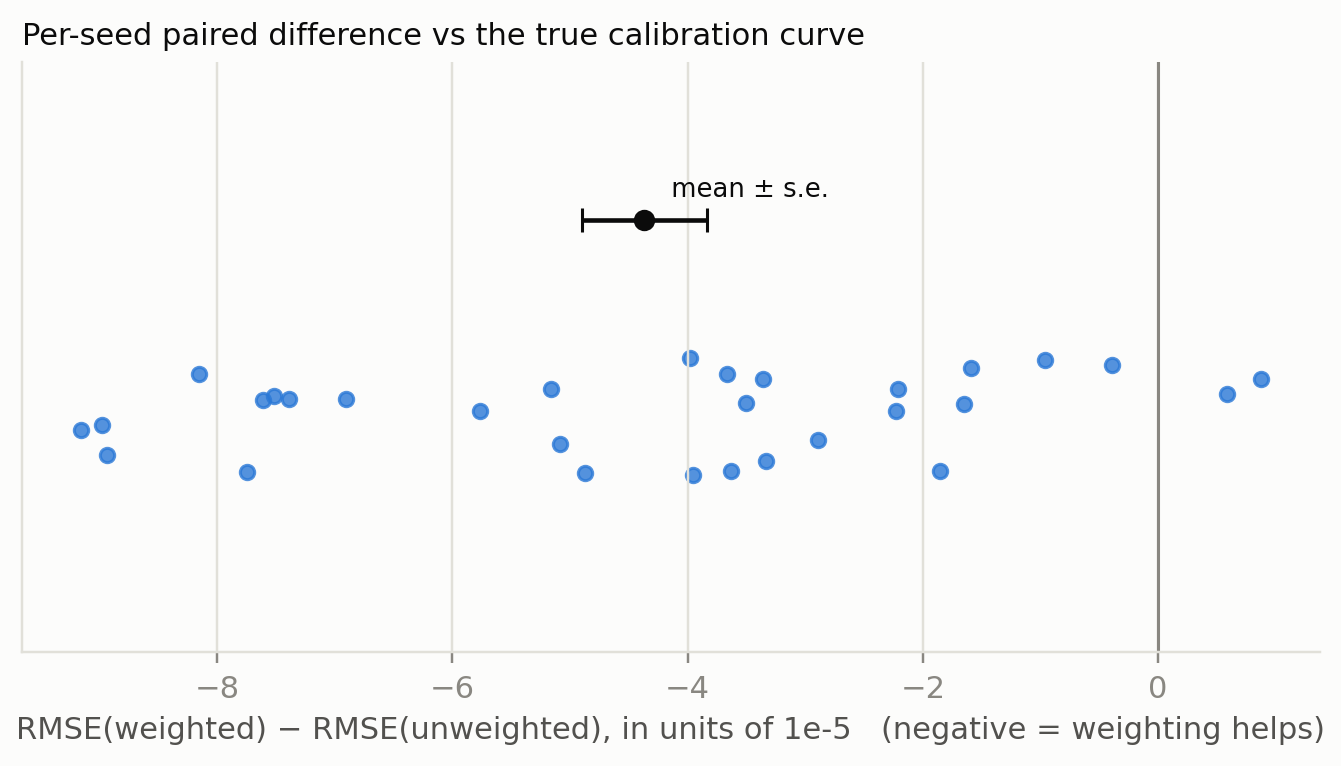

In [61]:
#@title Effects of Confidence Weighting

fig, ax = plt.subplots(figsize=(6.2, 3.6))
d = (res["box_safe"] - res["unweighted"]) * 1e5          # plotted in units of 1e-5
ax.axvline(0, color=MUTED, lw=1)
ax.scatter(d, np.zeros_like(d) + np.random.default_rng(0).uniform(-0.15, 0.15, len(d)), s=22, color=C["blue"], alpha=0.8)
ax.errorbar([d.mean()], [0.5], xerr=[d.std(ddof=1) / np.sqrt(len(d))], fmt="o", color=INK, capsize=4)
label(ax, d.mean(), 0.5, " mean ± s.e.", INK, dx=6, dy=10)
ax.set_ylim(-0.6, 0.9); ax.set_yticks([])
ax.set_xlabel("RMSE(weighted) − RMSE(unweighted), in units of 1e-5   (negative = weighting helps)")
ax.set_title("Per-seed paired difference vs the true calibration curve", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

Weighting lowers the error against the truth by about 0.5% (RMSE 0.00921 → 0.00916): small, but consistent — better in 28 of 30 seeds, a paired difference of about −4.4e-5 ± 0.5e-5 (roughly 9 standard errors). The *uncapped* variant has the **same accuracy** as the capped one, so the `min` does not buy accuracy. Rather, it buys the guarantee. On these realistic fits the uncapped weighting produced hundreds of non-monotone steps across the 30 fits (first printed line above), while the box-safe and unweighted versions produced none.

### D7. No Forced Anchors at $(0,0)$ and $(1,1)$ at the Endpoints

Continuing the end *tangent* (clipped to $[0,1]$) keeps the output monotone and avoids several undesirable effects of alternatives. Below we compare anchored, flat-clamp and tangent variants on two worlds: one where $h(0)=0,h(1)=1$ is true, and one with a 3% label-noise floor where it is false. Errors are measured against the known truth.

In [65]:
#@title Endpoint Behavior Comparison

def pool_ids(p, kept_bins, n_bins, fit):
    bin_to_fin = np.full(n_bins, -1); bin_to_fin[kept_bins] = np.arange(len(kept_bins))
    idx = np.minimum((np.clip(p, 0, 1) * n_bins).astype(np.int64), n_bins - 1)
    return fit["pool_of_bin"][bin_to_fin[idx]]

def edge_gaps(fit, p, kept_bins, n_bins, extrap):
    """Signed in-sample gap  mean(h(p)) - observed pool rate  for the first and last pool."""
    out = pchip_eval(fit["x"], fit["y"], fit["d"], p, extrap)
    k = pool_ids(p, kept_bins, n_bins, fit)
    last = fit["n_pools"] - 1
    return out[k == 0].mean() - fit["pool_rate"][0], out[k == last].mean() - fit["pool_rate"][last]

rows, store = [], {}
for world, floor in [("h(0)=0, h(1)=1 holds", 0.0), ("3% noise floor", 0.03)]:
    ptr, ytr = make_data(210_000, seed=11, floor=floor)
    pva, yva = make_data(90_000, seed=12, floor=floor)
    spk, syk, nk, kept = finalize(accumulate(ptr, ytr, N_BINS))
    tva = true_h(pva, floor)
    for name, anchor, extrap in [("anchored (0,0),(1,1)", True, "clamp"),
                                 ("unanchored + flat clamp", False, "clamp"),
                                 ("unanchored + tangent", False, "tangent")]:
        f = fit_curve(spk, syk, nk, anchor=anchor)
        o = pchip_eval(f["x"], f["y"], f["d"], pva, extrap)
        gl, gh = (np.nan, np.nan) if anchor else edge_gaps(f, ptr, kept, N_BINS, extrap)
        rows.append(dict(world=world, variant=name,
                         rmse_vs_truth_p_lt_0p02=np.sqrt(np.mean((o - tva)[pva < 0.02] ** 2)),
                         rmse_vs_truth_p_gt_0p98=np.sqrt(np.mean((o - tva)[pva > 0.98] ** 2)),
                         first_pool_gap=gl, last_pool_gap=gh,
                         val_Brier=brier_each(o, yva).mean(), val_ECE15=ece(o, yva)))
        store[(world, name)] = f
    store[(world, "data")] = (spk, syk, nk)
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.5f}"))

               world                 variant  rmse_vs_truth_p_lt_0p02  rmse_vs_truth_p_gt_0p98  first_pool_gap  last_pool_gap  val_Brier  val_ECE15
h(0)=0, h(1)=1 holds    anchored (0,0),(1,1)                  0.00489                  0.00614             NaN            NaN    0.18907    0.00605
h(0)=0, h(1)=1 holds unanchored + flat clamp                  0.00698                  0.00632         0.00298       -0.00649    0.18907    0.00598
h(0)=0, h(1)=1 holds    unanchored + tangent                  0.00547                  0.00519        -0.00002        0.00051    0.18907    0.00607
      3% noise floor    anchored (0,0),(1,1)                  0.00945                  0.00961             NaN            NaN    0.19609    0.00577
      3% noise floor unanchored + flat clamp                  0.00810                  0.00598         0.00233       -0.00545    0.19608    0.00532
      3% noise floor    unanchored + tangent                  0.00697                  0.00414        -0.00001  

**Reading the table:** (RMSE against the truth in the tails; lower is better)

* When $h(0)=0,h(1)=1$ really holds, anchoring is best at the low end (0.0049, against 0.0055 for tangent and 0.0070 for flat) (an assumption that happens to be true helps) but at the high end the tangent variant wins (0.0052 against 0.0061 anchored).
* With a 3% noise floor the anchored fit is clearly the worst at both ends (0.0095 and 0.0096, against 0.0070 and 0.0041 for tangent) as it forces the curve through points that are wrong.
* The flat clamp is never the best variant, and its first/last pool gaps (about +0.002 to +0.003 and −0.005 to −0.006) are the first-order bias described above. The tangent variant brings them to roughly zero.
* Validation Brier and ECE barely move, because the tails hold a small share of the loss. The edge choice matters for *tail calibration*, *ties* and the *table kink*, not for headline metrics.

So the tangent extension is the most robust choice that makes no assumption about $h(0)$ or $h(1)$ in this experiment.

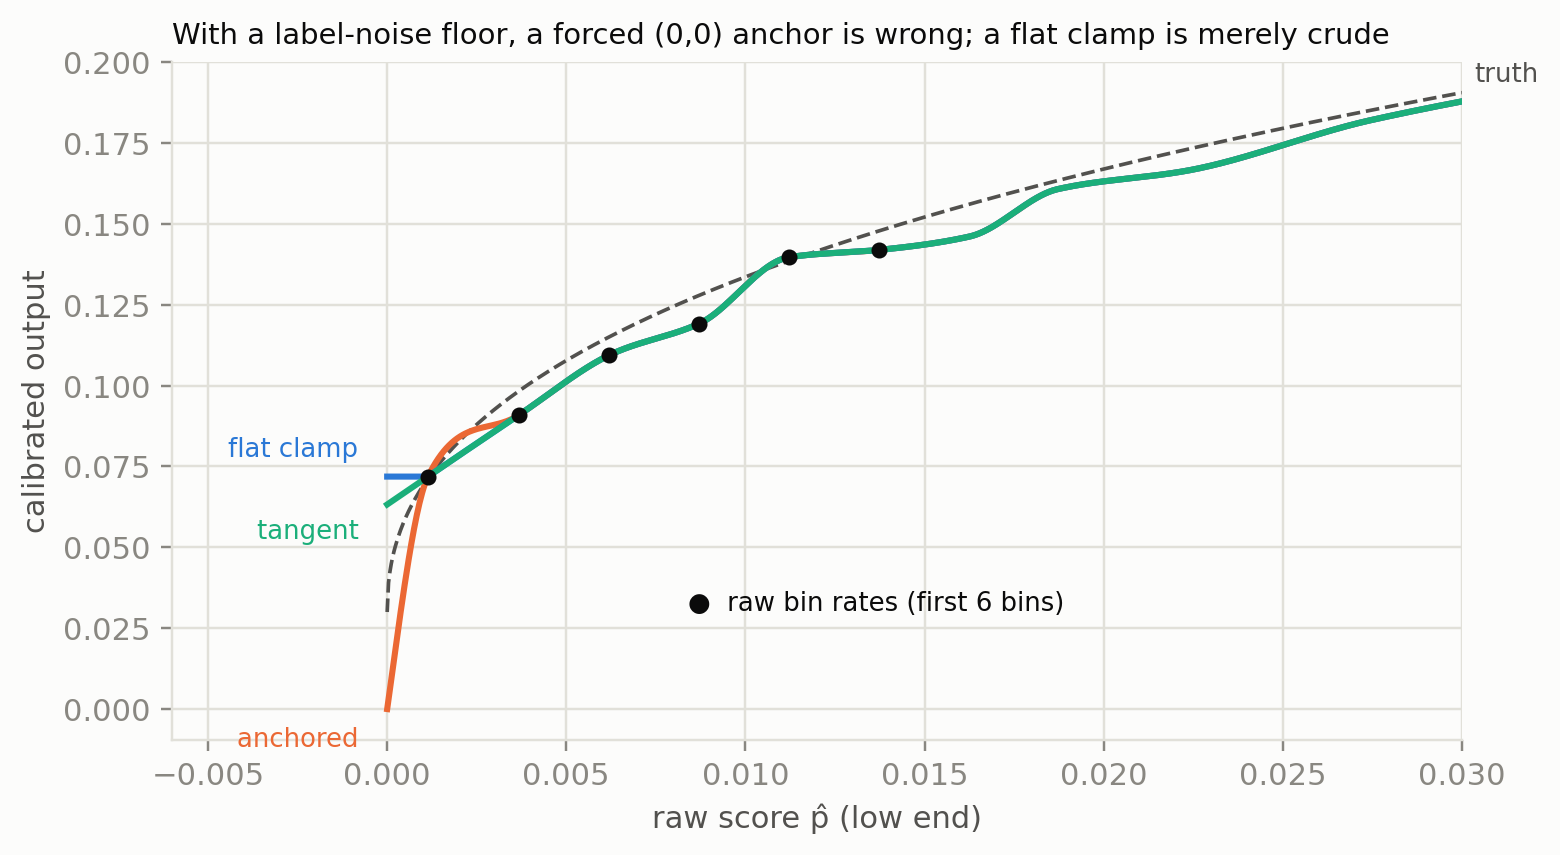

In [66]:
#@title Endpoint Behavior Demonstration

# Zoom at the low end of the noise-floor world: what do the three variants do below the first knot?
world = "3% noise floor"
spk, syk, nk = store[(world, "data")]
gg = np.linspace(0, 0.03, 800)
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(gg, true_h(np.maximum(gg, 1e-12), 0.03), color=INK2, lw=1.2, ls="--")
label(ax, gg[-1], true_h(np.array([gg[-1]]), 0.03)[0], "truth", INK2, dx=4, dy=6)
spec = [("anchored (0,0),(1,1)", True, "clamp", C["orange"], "anchored"),
        ("unanchored + flat clamp", False, "clamp", C["blue"], "flat clamp"),
        ("unanchored + tangent", False, "tangent", C["aqua"], "tangent")]
for (name, anchor, extrap, col, short), dy in zip(spec, [-10, 9, -9]):
    f = store[(world, name)]
    v = pchip_eval(f["x"], f["y"], f["d"], gg, extrap)
    ax.plot(gg, v, color=col, lw=2)
    label(ax, 0.0, v[0], short + "  ", col, dx=-4, dy=dy, ha="right")
ax.scatter(spk[:6] / nk[:6], syk[:6] / nk[:6], s=18, color=INK, zorder=4)     # bin MEAN score vs bin rate
key(ax, [("●  raw bin rates (first 6 bins)", INK)], x=0.40, y=0.22)
ax.set_xlim(-0.006, 0.03)
ax.set_xlabel("raw score p̂ (low end)")
ax.set_ylabel("calibrated output")
ax.set_title("With a label-noise floor, a forced (0,0) anchor is wrong; a flat clamp is merely crude", loc="left", fontsize=9.5, color=INK)
plt.tight_layout()
plt.show()

### D8. A Lookup Table of $\delta(p)=h(p)-p$ on a Uniform Grid (`n_grid`)

Offline, evaluate the fitted curve on a uniform grid $p_i=i/(G-1)$ and store $\delta_i=h(p_i)-p_i$. At inference, the cell containing $p$ is found by **index arithmetic**, $i=\lfloor p\,(G-1)\rfloor$, followed by one linear interpolation: $h(p)=p+\delta_i+\text{frac}\cdot(\delta_{i+1}-\delta_i)$, where $\text{frac}=p\,(G-1)-i\in[0,1)$.

**Rationale:**

* **O(1) "bin lookups":** A uniform grid needs no binary search. The bin index can be directly computed. (In the C++ implementation this measured about 3–4 ns per call, single-threaded.)
* **Thread safe:** The table is immutable, so it can be shared across threads without locking.

### 9. Putting it Together

#### Held-out comparison

We compare against the raw score, a parametric Platt scaling (a logistic fit on the logits, it cannot represent the bump in the simulated model), scikit-learn's isotonic regression fitted on the raw samples, and the intermediate stages of this pipeline.

In [67]:
#@title Comparison Table

platt = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_tr)[:, None], y_tr)
iso = IsotonicRegression(out_of_bounds="clip").fit(p_tr, y_tr)
final = dict(base)
methods = {
    "raw score":               p_va,
    "Platt (logit-linear)":    platt.predict_proba(logit(p_va)[:, None])[:, 1],
    "sklearn isotonic":        iso.predict(p_va),
    "PAV step (stage 2)":      step_apply(p_va, final, N_BINS, bin_idx),
    "linear interp (stage 3)": np.interp(p_va, final["x"], final["y"]),
    "PCHIP, z=0 (this method)": out0,
    "PCHIP, z=2":              pchip_eval(*[fit_curve(sp_b, sy_b, n_b, z=2.0)[k] for k in ("x", "y", "d")], p_va),
}
rows = []
for k, v in methods.items():
    db, sb = paired(brier_each(v, y_va), brier_each(out0, y_va))
    rows.append(dict(method=k, ROC_AUC=roc_auc_score(y_va, v), Brier=brier_each(v, y_va).mean(),
                     LogLoss=logloss_each(v, y_va).mean(), ECE15=ece(v, y_va, 15), ECE100=ece(v, y_va, 100),
                     unique=len(np.unique(v)), dBrier_vs_ours=f"{db:+.1e} ± {sb:.0e}"))
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.5f}"))

                  method  ROC_AUC   Brier  LogLoss   ECE15  ECE100  unique   dBrier_vs_ours
               raw score  0.77952 0.21227  0.67252 0.13330 0.13338   90000 +2.2e-02 ± 4e-04
    Platt (logit-linear)  0.77952 0.19090  0.56082 0.01412 0.01721   90000 +3.5e-04 ± 6e-05
        sklearn isotonic  0.77940 0.19057  0.56054 0.00545 0.01032     204 +2.6e-05 ± 2e-05
      PAV step (stage 2)  0.77937 0.19058  0.56019 0.00584 0.00953      90 +3.3e-05 ± 2e-05
 linear interp (stage 3)  0.77952 0.19054  0.56005 0.00517 0.01097   87729 -4.9e-06 ± 3e-06
PCHIP, z=0 (this method)  0.77952 0.19055  0.56006 0.00515 0.01106   87731 +0.0e+00 ± 0e+00
              PCHIP, z=2  0.77952 0.19054  0.56005 0.00496 0.01050   87870 -8.0e-06 ± 1e-05


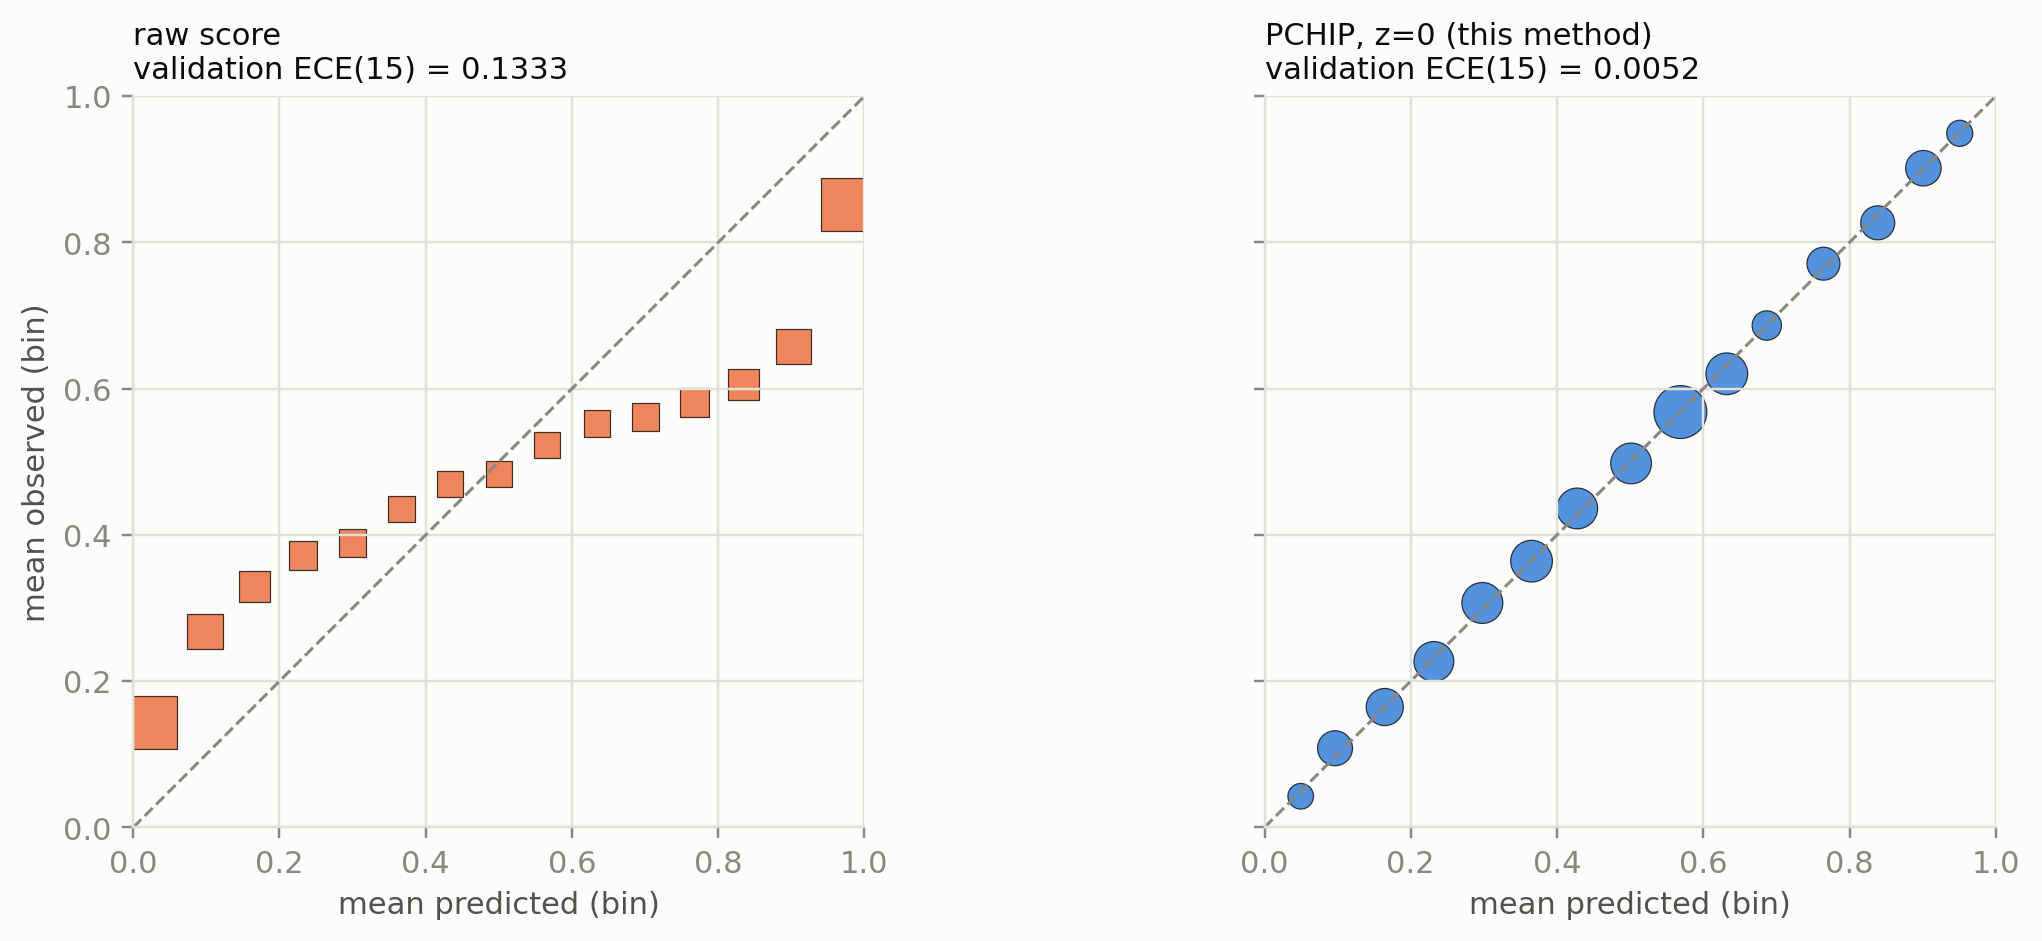

In [68]:
#@title Results on the Reliability Diagram

def reliability(p, y, nb=15):
    idx = np.minimum((np.clip(p, 0, 1) * nb).astype(np.int64), nb - 1)
    n = np.bincount(idx, minlength=nb); sp = np.bincount(idx, weights=p, minlength=nb); sy = np.bincount(idx, weights=y, minlength=nb)
    m = n > 0
    return sp[m] / n[m], sy[m] / n[m], n[m]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for a, (name, v, col, mk) in zip(ax, [("raw score", p_va, C["orange"], "s"), ("PCHIP, z=0 (this method)", out0, C["blue"], "o")]):
    mp, mo, n = reliability(v, y_va)
    a.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
    a.scatter(mp, mo, s=20 + 280 * n / n.max(), color=col, marker=mk, alpha=0.8, edgecolor=INK, linewidth=0.4)
    a.set_title(f"{name}\nvalidation ECE(15) = {ece(v, y_va):.4f}", loc="left", fontsize=10, color=INK)
    a.set_xlabel("mean predicted (bin)"); a.set_xlim(0, 1); a.set_ylim(0, 1); a.set_aspect("equal")
ax[0].set_ylabel("mean observed (bin)")
plt.tight_layout(); plt.show()

#### Why isn't the *in-sample* reliability diagram perfect?

One might expect the following: calibrate on a dataset, evaluate on the same dataset, and get a perfect diagonal. That is exactly true for the **PAV step function** (each pool's output *is* its observed rate, so any reliability bin is a union of whole pools). However, this is not true for the interpolated curve.

### 10. Misc.

**What to tune:** `n_bins` (number of bins) and `z_threshold` are plain parameters chosen offline on held-out data. With limited calibration data, the defaults are usually the best choice because differences between reasonable settings are typically smaller than the noise in measuring them. If you do tune `n_bins` or `z_threshold`, use K-fold cross-fitting on the calibration set (fit on K−1 folds, evaluate on the held-out fold, using the same folds for every candidate) and select on log loss (`evaluation.loss`). Treat any candidate whose mean log loss is within one standard error of the best (SE = sd of per-fold differences / $\sqrt{K}$) as a tie, and prefer the default among ties. Use ECE and MCE as sanity checks, not as selection criteria. Both depend on their own binning, are noisy (MCE especially, since it is set by a single bin), and can reward over-smoothed curves.

**References:**
* F. N. Fritsch & R. E. Carlson (1980), *Monotone piecewise cubic interpolation*, SIAM J. Numer. Anal. 17(2):238–246.
* M. Ayer et al. (1955), *An empirical distribution function for sampling with incomplete information*, Ann. Math. Stat. 26(4).
* R. E. Barlow et al. (1972), *Statistical Inference under Order Restrictions*, Wiley.